In [10]:
import numpy as np
import pandas as pd
import glob
import os
import re
from pathlib import Path

# Resolve local paths for this repo
cwd = Path.cwd()
base_dir = cwd if (cwd / "processeddata").exists() else (cwd / "..").resolve()

outcomes_path = base_dir / "processeddata" / "Randomization factors and Primary outcome.xlsx"
output_dir = str(base_dir / "processeddata")

# Load outcomes and compute Diff
df = pd.read_excel(outcomes_path)
diff = df[df["Event Name"].isin(["T1", "T2"])].pivot_table(
    index="Patient number", columns="Event Name", values="Pain Unpleasantness"
).dropna()
diff["Diff"] = diff["T2"] - diff["T1"]
diff_with_xlsx = diff  # Alias for compatibility with Cell 2

#median for binary or vmin, vmax = -3, -2  for 3 classes
median_threshold = -3.00
sheet_name = "Z_FFT_Coherence"

# Delta	           Theta	       Alpha	      Beta	        HighBeta        Alpha1	          Alpha2	       Beta1	          Beta2	          Beta3
# 0.401±0.114    0.362±0.102    0.527±0.127    0.604±0.120    0.510±0.102      0.492±0.110     0.432±0.100      0.539±0.109        0.524±0.110     0.606±0.099
# Column selection for Z_FFT_Coherence sheet
# Available columns: Delta, Theta, Alpha, Beta, HighBeta, Alpha1, Alpha2, Beta1, Beta2, Beta3
# Option 1: Use all columns (set to None or empty list)
# Option 2: Select specific columns (e.g., ["Delta", "Theta", "Alpha"])
# Option 3: Use frequency bands (e.g., ["Delta", "Theta", "Alpha", "Beta", "HighBeta"])
# Option 4: Use sub-bands (e.g., ["Alpha1", "Alpha2", "Beta1", "Beta2", "Beta3"])
selected_columns = ["Alpha","Beta1", "Beta2", "Beta3"]  #["Alpha","Beta1", "Beta2", "Beta3"]  # Change to list of column names to select specific columns, e.g., ["Delta", "Theta", "Alpha"]

# ----------------------------
# Helpers
# ----------------------------
# Returns: dict mapping patient_id (int) -> filepath (str)
# Example: {1: "/path/to/CIPN3001_NFB.xlsx", 2: "/path/to/CIPN3002_NFB.xlsx", ...}
def build_patient_map(output_dir: str) -> dict:
    xlsx_files = glob.glob(os.path.join(output_dir, "CIPN3*.xlsx"))
    patient_ids = {}
    for f in xlsx_files:
        m = re.search(r"CIPN3(\d{3})", os.path.basename(f))
        if m:
            patient_ids[int(m.group(1))] = f
    return patient_ids

# Input: df (pd.DataFrame) - shape depends on sheet type:
#   - Bandpower sheets: (n_channels, n_bands) e.g., (19, 15) for 19 channels × 15 bands
#   - Connectivity sheets: (N, N) e.g., (19, 19) for 19×19 connectivity matrix
#   - Vector sheets: (n_channels, 1) or (n_channels, n_freqs)
# Output: np.ndarray - 1D feature vector, shape (n_features,)
#   - Connectivity: ~10 features (5 edge stats + 5 node strength stats)
#   - Bandpower: ~(n_bands × 3 + 3) features (mean/std/median per band + 3 global stats)
#   - Vector: 5 features (mean/std/median/75th/90th percentile)
def sheet_to_features(df: pd.DataFrame, sheet_name: str) -> np.ndarray:
    """
    Convert a sheet dataframe into a compact feature vector.
    Works for:
      - bandpower-like tables (channels x bands): summary over channels per band
      - connectivity-like tables (NxN): summary over upper triangle + node strengths
      - 1D tables/vectors: simple stats
    """
    # A shape: same as df.values, typically (n_channels, n_bands) or (N, N) or (n_channels, n_freqs)
    A = df.values.astype(float)
    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)

    feats = []

    # Case 1: square matrix -> treat as connectivity
    # A shape: (N, N) where N = number of channels/nodes (e.g., 19×19)
    if A.ndim == 2 and A.shape[0] == A.shape[1] and A.shape[0] >= 4 and ("Coherence" in sheet_name or "PLI" in sheet_name):
        n = A.shape[0]  # n = N (e.g., 19)
        # triu shape: (n*(n-1)/2,) - upper triangle elements (e.g., 171 for 19×19)
        triu = A[np.triu_indices(n, k=1)]
        # feats: 5 scalar values (mean, std, median, 75th, 90th percentile of edges)
        feats += [
            triu.mean(), triu.std(), np.median(triu),
            np.percentile(triu, 75), np.percentile(triu, 90)
        ]
        # node strength (sum of edges per node)
        # strength shape: (n,) - one value per node (e.g., (19,))
        strength = A.sum(axis=1) - np.diag(A)
        # feats: additional 5 scalar values (mean, std, median, 75th, 90th percentile of node strengths)
        feats += [
            strength.mean(), strength.std(), np.median(strength),
            np.percentile(strength, 75), np.percentile(strength, 90)
        ]
        # Return shape: (10,) - 10 features total for connectivity
        return np.array(feats, dtype=float)

    # Case 2: bandpower-like (channels x bands) -> summarize per column (band)
    # A shape: (n_channels, n_bands) e.g., (19, 15) for 19 channels × 15 bands
    if A.ndim == 2 and A.shape[0] >= 4 and A.shape[1] >= 2:
        # Per-column stats (each column often corresponds to a band)
        # col_mean, col_std, col_med shape: (n_bands,) e.g., (15,)
        col_mean = A.mean(axis=0)
        col_std  = A.std(axis=0)
        col_med  = np.median(A, axis=0)
        # feats: n_bands + n_bands + n_bands = 3*n_bands values (e.g., 45 for 15 bands)
        feats.extend(col_mean.tolist())
        feats.extend(col_std.tolist())
        feats.extend(col_med.tolist())
        # Global stats too
        # feats: additional 3 scalar values (global mean, std, median)
        feats += [A.mean(), A.std(), np.median(A)]
        # Return shape: (3*n_bands + 3,) e.g., (48,) for 15 bands
        return np.array(feats, dtype=float)

    # Case 3: vector-ish
    # v shape: (n_total_elements,) - flattened array
    v = A.flatten()
    # feats: 5 scalar values (mean, std, median, 75th, 90th percentile)
    feats += [v.mean(), v.std(), np.median(v), np.percentile(v, 75), np.percentile(v, 90)]
    # Return shape: (5,)
    return np.array(feats, dtype=float)

# Input: patient_ids (dict), patient_nums (list), sheet_name (str), selected_columns (list or None)
# Output: X (np.ndarray) shape (n_samples, n_features), kept (list) shape (n_samples,)
#   - n_samples = number of patients successfully loaded
#   - n_features = depends on sheet type (see sheet_to_features above)
def load_features_for_sheet(patient_ids: dict, patient_nums: list, sheet_name: str, selected_columns=None):
    X_list, kept = [], []
    for p in patient_nums:
        path = patient_ids.get(p)
        if path is None:
            continue
        try:
            # df_sheet shape: depends on sheet (e.g., (19, 15) for bandpower, (19, 19) for connectivity)
            df_sheet = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
            
            # Filter columns if selected_columns is provided
            if selected_columns is not None and len(selected_columns) > 0:
                # Check which columns exist in the dataframe
                available_cols = df_sheet.columns.tolist()
                cols_to_use = [col for col in selected_columns if col in available_cols]
                if len(cols_to_use) == 0:
                    print(f"  Warning: None of the selected columns found for patient {p}. Available: {available_cols}")
                    continue
                if len(cols_to_use) < len(selected_columns):
                    missing = set(selected_columns) - set(cols_to_use)
                    print(f"  Warning: Patient {p} missing columns: {missing}")
                df_sheet = df_sheet[cols_to_use]
            
            # feat shape: (n_features,) - 1D feature vector (see sheet_to_features)
            feat = sheet_to_features(df_sheet, sheet_name)
            X_list.append(feat)
            kept.append(p)
        except Exception as e:
            print(f"  Error loading patient {p} in {sheet_name}: {e}")
    if len(X_list) == 0:
        return None, []
    # X shape: (n_samples, n_features) - stacked feature vectors
    #   Example: (75, 48) for 75 patients × 48 features (if bandpower with 15 bands)
    #   Example: (75, 10) for 75 patients × 10 features (if connectivity)
    X = np.vstack(X_list)
    return X, kept

In [28]:
# Load features for all patients
patient_ids = build_patient_map(output_dir)
patient_nums = list(patient_ids.keys())

X, kept_patients = load_features_for_sheet(
    patient_ids, patient_nums, sheet_name, selected_columns
)

print(f"Loaded features for {len(kept_patients)} patients")
print(f"Feature matrix shape: {X.shape}")


Loaded features for 78 patients
Feature matrix shape: (78, 15)


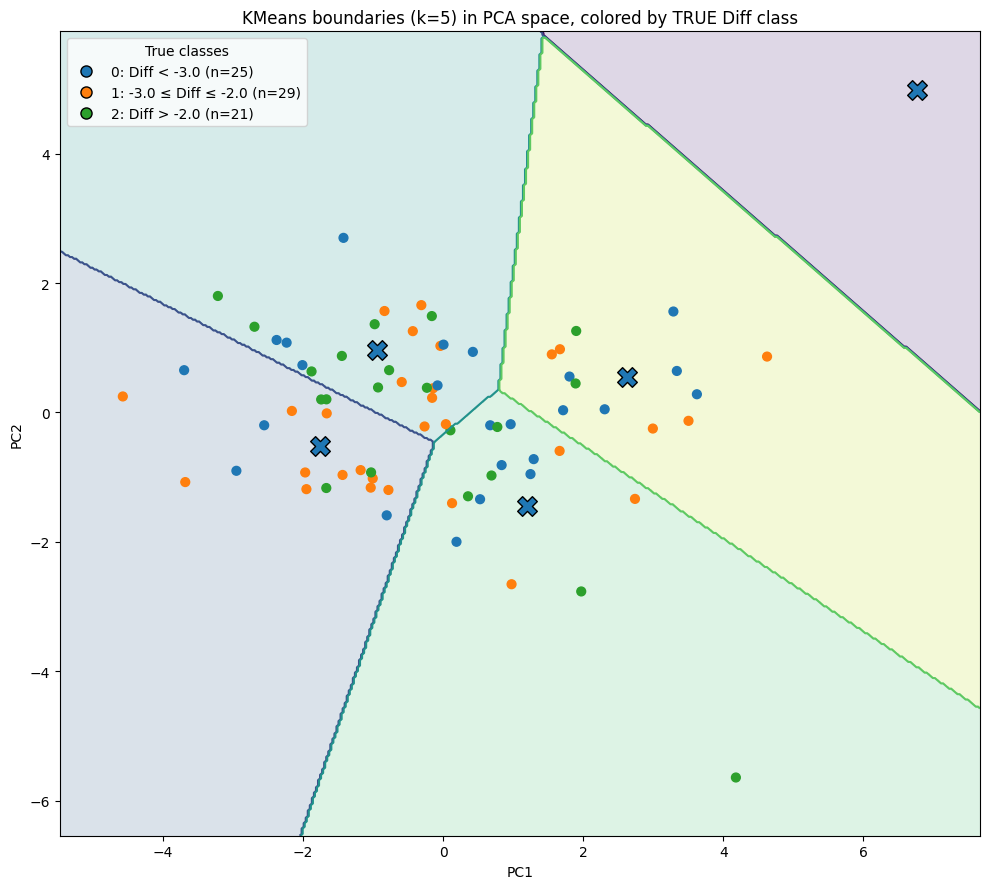

In [12]:
# ============================================================
# PCA (PC1/PC2) + KMeans boundaries (Voronoi regions in PCA space)
# Points colored by TRUE Diff classes (0/1/2) computed from Diff thresholds
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

# -----------------------
# Params
# -----------------------
vmin, vmax = -3.0, -2.0
k = 5
grid_res = 450   # 300-600; higher = smoother boundaries
pad = 0.9        # margin around PCA points

# -----------------------
# Data should already be loaded from previous cells:
#   X, kept_patients, diff_with_xlsx (indexed by patient number, has "Diff")
# -----------------------
assert "kept_patients" in globals(), "kept_patients must exist"
assert "diff_with_xlsx" in globals(), "diff_with_xlsx must exist"
assert "Diff" in diff_with_xlsx.columns, "diff_with_xlsx must have column 'Diff'"
assert len(kept_patients) == X.shape[0], "kept_patients must align with X rows"

# Align Diff to X rows and build TRUE labels from threshold logic
summary = pd.DataFrame({"Patient": kept_patients})
summary["Diff"] = summary["Patient"].map(diff_with_xlsx["Diff"])

# Drop missing Diff rows (and the corresponding X rows) to avoid label bugs
mask = summary["Diff"].notna().values
if mask.sum() != len(mask):
    print(f"WARNING: Dropping {len(mask) - mask.sum()} rows with missing Diff.")
summary = summary.loc[mask].reset_index(drop=True)
X = X[mask]

diff_vals = summary["Diff"].values
y_true = np.where(diff_vals < vmin, 0, np.where(diff_vals > vmax, 2, 1)).astype(int)

# -----------------------
# Scale -> KMeans -> PCA
# -----------------------
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

km = KMeans(n_clusters=k, n_init=50, random_state=42)
cluster = km.fit_predict(Xz)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Xz)  # (N, 2)

# Centers in PCA space (for Voronoi regions)
centers_pc = pca.transform(km.cluster_centers_)  # (k, 2)

# -----------------------
# Grid + Voronoi regions in PCA space (nearest center)
# -----------------------
x_min, x_max = Z[:, 0].min() - pad, Z[:, 0].max() + pad
y_min, y_max = Z[:, 1].min() - pad, Z[:, 1].max() + pad

# x_min, x_max = np.quantile(Z[:,0], [0.01, 0.99])
# y_min, y_max = np.quantile(Z[:,1], [0.01, 0.99])

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, grid_res),
    np.linspace(y_min, y_max, grid_res)
)
grid = np.c_[xx.ravel(), yy.ravel()]  # (M, 2)

d2 = ((grid[:, None, :] - centers_pc[None, :, :]) ** 2).sum(axis=2)  # (M, k)
Zgrid = np.argmin(d2, axis=1).reshape(xx.shape)

# -----------------------
# Discrete colors for TRUE classes (0/1/2)
# -----------------------
cmap3 = ListedColormap(["tab:blue", "tab:orange", "tab:green"])
norm3 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], ncolors=3)
counts_true = {c: int((y_true == c).sum()) for c in [0, 1, 2]}

true_labels = {
    0: f"0: Diff < {vmin} (n={counts_true[0]})",
    1: f"1: {vmin} ≤ Diff ≤ {vmax} (n={counts_true[1]})",
    2: f"2: Diff > {vmax} (n={counts_true[2]})",
}

handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor=cmap3(i), markeredgecolor='k',
           markersize=8, label=true_labels[i])
    for i in [0, 1, 2]
]

# -----------------------
# Plot: KMeans boundaries + points colored by TRUE classes
# -----------------------
plt.figure(figsize=(10, 9))

# KMeans regions (light fill) + boundary lines
plt.contourf(xx, yy, Zgrid, levels=np.arange(-0.5, k + 0.5, 1), alpha=0.18)
plt.contour(xx, yy, Zgrid, levels=np.arange(0, k), linewidths=1.5)

# Points colored by TRUE class
plt.scatter(Z[:, 0], Z[:, 1], c=y_true, cmap=cmap3, norm=norm3, s=40)

# KMeans centers (X marker)
plt.scatter(centers_pc[:, 0], centers_pc[:, 1], marker="X", s=200, edgecolors="k")

plt.title(f"KMeans boundaries (k={k}) in PCA space, colored by TRUE Diff class")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(handles=handles, title="True classes", loc="best", frameon=True)
plt.tight_layout()
plt.show()


In [13]:
import numpy as np
print("Cluster counts:", np.bincount(cluster, minlength=k))


Cluster counts: [ 1 22 23 16 13]


In [14]:
# assign each point to nearest PCA-projected center (same rule as your grid)
d2_pts = ((Z[:, None, :] - centers_pc[None, :, :])**2).sum(axis=2)  # (N,k)
region_of_point = np.argmin(d2_pts, axis=1)

print("Points per PCA-Voronoi region:", np.bincount(region_of_point, minlength=k))


Points per PCA-Voronoi region: [ 1 19 25 17 13]


In [15]:
x_min, x_max = np.quantile(Z[:,0], [0.01, 0.99])
y_min, y_max = np.quantile(Z[:,1], [0.01, 0.99])


In [16]:
y_true

array([0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 2, 0, 0, 2, 0, 1, 0, 2, 2, 0, 0, 2,
       1, 0, 1, 2, 2, 1, 1, 2, 1, 0, 1, 0, 0, 1, 1, 1, 2, 1, 1, 0, 1, 0,
       2, 2, 1, 1, 2, 2, 0, 1, 1, 0, 0, 0, 0, 2, 0, 1, 2, 1, 1, 1, 2, 0,
       2, 2, 0, 0, 2, 1, 0, 1, 1])

In [17]:
vmin, vmax = -3.0, -2.0
y_true = np.where(diff_vals < vmin, 0, np.where(diff_vals > vmax, 2, 1)).astype(int)

In [18]:
# Aggregate unique sheet names across all patient files
import pandas as pd

def get_unique_sheet_names(patient_ids: dict) -> list:
    """Return sorted unique Excel sheet names across all patient files."""
    unique = set()
    for pid, path in patient_ids.items():
        try:
            xls = pd.ExcelFile(path)
            unique.update(xls.sheet_names)
        except Exception as exc:
            print(f"Warning: failed to read sheets for patient {pid}: {exc}")
    return sorted(unique)

all_unique_sheets = get_unique_sheet_names(patient_ids)
print(f"Unique sheets across {len(patient_ids)} patients: {len(all_unique_sheets)}")
print(all_unique_sheets)


Unique sheets across 78 patients: 17
['FFT_Coherence', 'FFT_PhaseLag_PLI', 'FFT_abs_1to50Hz_uV2', 'FFT_abs_bandpower_uV2', 'FFT_rel_1to50Hz_pct', 'FFT_rel_bandpower_pct', 'PeakFreq_Hz', 'Z_FFT_Coherence', 'Z_FFT_PhaseLag_PLI', 'Z_FFT_abs_1to30Hz_uV2', 'Z_FFT_abs_1to50Hz_uV2', 'Z_FFT_abs_bandpower_uV2', 'Z_FFT_rel_1to30Hz_pct', 'Z_FFT_rel_1to50Hz_pct', 'Z_FFT_rel_bandpower_pct', 'Z_PeakFreq_Hz', 'meta']


Cluster counts: [26 25 23  1]
Outlier clusters (size < 5 ): [3]
Outlier patient IDs: [328]
Kept patients after removal: 74


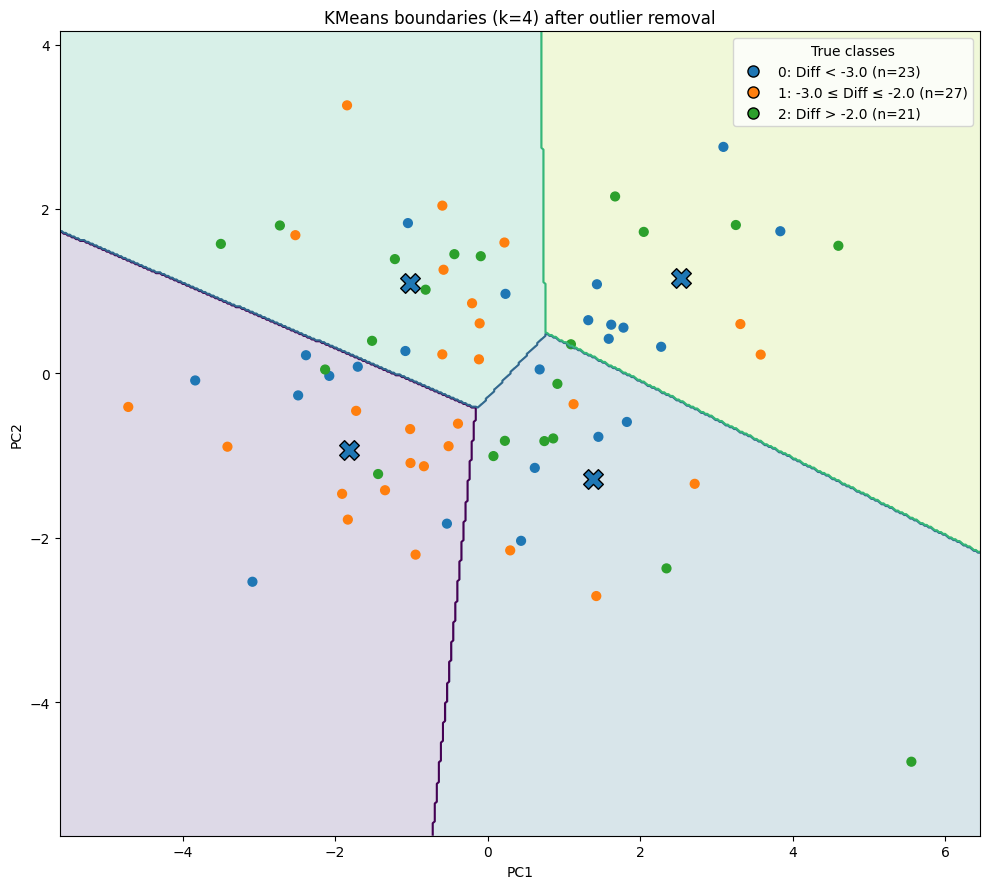

In [25]:
# Identify outlier clusters, list patients, remove them, and re-run clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

# ---- Settings ----
# Set k=7 here if you want seven regions
k = 4
min_cluster_size = 5  # clusters with fewer points are treated as outliers
vmin, vmax = -3.0, -2.0
pad = 0.9
grid_res = 450

# Ensure prerequisites exist (load if missing)
if "X" not in globals() or "kept_patients" not in globals():
    import glob
    import os
    import re
    from pathlib import Path

    # Resolve local paths (same logic as the first cell)
    if "output_dir" not in globals():
        cwd = Path.cwd()
        base_dir = cwd if (cwd / "processeddata").exists() else (cwd / "..").resolve()
        output_dir = str(base_dir / "processeddata")

    if "diff_with_xlsx" not in globals():
        outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
        df = pd.read_excel(outcomes_path)
        diff = df[df["Event Name"].isin(["T1", "T2"])].pivot_table(
            index="Patient number", columns="Event Name", values="Pain Unpleasantness"
        ).dropna()
        diff["Diff"] = diff["T2"] - diff["T1"]
        diff_with_xlsx = diff

    if "sheet_name" not in globals():
        sheet_name = "Z_FFT_Coherence"
    if "selected_columns" not in globals():
        selected_columns = None

    if "build_patient_map" not in globals():
        def build_patient_map(output_dir: str) -> dict:
            xlsx_files = glob.glob(os.path.join(output_dir, "CIPN3*.xlsx"))
            patient_ids = {}
            for f in xlsx_files:
                m = re.search(r"CIPN3(\d{3})", os.path.basename(f))
                if m:
                    patient_ids[int(m.group(1))] = f
            return patient_ids

    if "sheet_to_features" not in globals():
        def sheet_to_features(df: pd.DataFrame, sheet_name: str) -> np.ndarray:
            A = df.values.astype(float)
            A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)

            feats = []

            if A.ndim == 2 and A.shape[0] == A.shape[1] and A.shape[0] >= 4 and ("Coherence" in sheet_name or "PLI" in sheet_name):
                n = A.shape[0]
                triu = A[np.triu_indices(n, k=1)]
                feats += [
                    triu.mean(), triu.std(), np.median(triu),
                    np.percentile(triu, 75), np.percentile(triu, 90)
                ]
                strength = A.sum(axis=1) - np.diag(A)
                feats += [
                    strength.mean(), strength.std(), np.median(strength),
                    np.percentile(strength, 75), np.percentile(strength, 90)
                ]
                return np.array(feats, dtype=float)

            if A.ndim == 2 and A.shape[0] >= 4 and A.shape[1] >= 2:
                col_mean = A.mean(axis=0)
                col_std  = A.std(axis=0)
                col_med  = np.median(A, axis=0)
                feats.extend(col_mean.tolist())
                feats.extend(col_std.tolist())
                feats.extend(col_med.tolist())
                feats += [A.mean(), A.std(), np.median(A)]
                return np.array(feats, dtype=float)

            v = A.flatten()
            feats += [v.mean(), v.std(), np.median(v), np.percentile(v, 75), np.percentile(v, 90)]
            return np.array(feats, dtype=float)

    if "load_features_for_sheet" not in globals():
        def load_features_for_sheet(patient_ids: dict, patient_nums: list, sheet_name: str, selected_columns=None):
            X_list, kept = [], []
            for p in patient_nums:
                path = patient_ids.get(p)
                if path is None:
                    continue
                try:
                    df_sheet = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
                    if selected_columns is not None and len(selected_columns) > 0:
                        available_cols = df_sheet.columns.tolist()
                        cols_to_use = [col for col in selected_columns if col in available_cols]
                        if len(cols_to_use) == 0:
                            print(f"  Warning: None of the selected columns found for patient {p}. Available: {available_cols}")
                            continue
                        if len(cols_to_use) < len(selected_columns):
                            missing = set(selected_columns) - set(cols_to_use)
                            print(f"  Warning: Patient {p} missing columns: {missing}")
                        df_sheet = df_sheet[cols_to_use]
                    feat = sheet_to_features(df_sheet, sheet_name)
                    X_list.append(feat)
                    kept.append(p)
                except Exception as e:
                    print(f"  Error loading patient {p} in {sheet_name}: {e}")
            if len(X_list) == 0:
                return None, []
            X = np.vstack(X_list)
            return X, kept

    patient_ids = build_patient_map(output_dir)
    patient_nums = list(patient_ids.keys())
    X, kept_patients = load_features_for_sheet(
        patient_ids, patient_nums, sheet_name, selected_columns
    )

# Scale and initial clustering
scaler = StandardScaler()
Xz = scaler.fit_transform(X)
km = KMeans(n_clusters=k, n_init=50, random_state=42)
cluster = km.fit_predict(Xz)

# Identify outlier clusters by size
counts = np.bincount(cluster, minlength=k)
outlier_clusters = np.where(counts < min_cluster_size)[0]
print("Cluster counts:", counts)
print("Outlier clusters (size <", min_cluster_size, "):", outlier_clusters.tolist())

# List patients in outlier clusters
outlier_patients = [pid for pid, c in zip(kept_patients, cluster) if c in outlier_clusters]
print("Outlier patient IDs:", outlier_patients)

# Remove outlier patients
keep_mask = np.array([c not in outlier_clusters for c in cluster])
X_filt = X[keep_mask]
kept_patients_filt = [pid for pid, keep in zip(kept_patients, keep_mask) if keep]
print(f"Kept patients after removal: {len(kept_patients_filt)}")

# Align Diff to filtered patients
summary_filt = pd.DataFrame({"Patient": kept_patients_filt})
summary_filt["Diff"] = summary_filt["Patient"].map(diff_with_xlsx["Diff"])
mask_diff = summary_filt["Diff"].notna().values
if mask_diff.sum() != len(mask_diff):
    print(f"WARNING: Dropping {len(mask_diff) - mask_diff.sum()} rows with missing Diff.")
summary_filt = summary_filt.loc[mask_diff].reset_index(drop=True)
X_filt = X_filt[mask_diff]

# Recompute true labels
diff_vals = summary_filt["Diff"].values
y_true = np.where(diff_vals < vmin, 0, np.where(diff_vals > vmax, 2, 1)).astype(int)

# Re-run clustering on filtered data
scaler = StandardScaler()
Xz = scaler.fit_transform(X_filt)
km = KMeans(n_clusters=k, n_init=50, random_state=42)
cluster = km.fit_predict(Xz)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Xz)
centers_pc = pca.transform(km.cluster_centers_)

# Plot with KMeans boundaries + true labels
x_min, x_max = Z[:, 0].min() - pad, Z[:, 0].max() + pad
y_min, y_max = Z[:, 1].min() - pad, Z[:, 1].max() + pad
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, grid_res),
    np.linspace(y_min, y_max, grid_res)
)
grid = np.c_[xx.ravel(), yy.ravel()]
d2 = ((grid[:, None, :] - centers_pc[None, :, :]) ** 2).sum(axis=2)
Zgrid = np.argmin(d2, axis=1).reshape(xx.shape)

cmap3 = ListedColormap(["tab:blue", "tab:orange", "tab:green"])
norm3 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], ncolors=3)
counts_true = {c: int((y_true == c).sum()) for c in [0, 1, 2]}
true_labels = {
    0: f"0: Diff < {vmin} (n={counts_true[0]})",
    1: f"1: {vmin} ≤ Diff ≤ {vmax} (n={counts_true[1]})",
    2: f"2: Diff > {vmax} (n={counts_true[2]})",
}
handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor=cmap3(i), markeredgecolor='k',
           markersize=8, label=true_labels[i])
    for i in [0, 1, 2]
]

plt.figure(figsize=(10, 9))
plt.contourf(xx, yy, Zgrid, levels=np.arange(-0.5, k + 0.5, 1), alpha=0.18)
plt.contour(xx, yy, Zgrid, levels=np.arange(0, k), linewidths=1.5)
plt.scatter(Z[:, 0], Z[:, 1], c=y_true, cmap=cmap3, norm=norm3, s=40)
plt.scatter(centers_pc[:, 0], centers_pc[:, 1], marker="X", s=200, edgecolors="k")
plt.title(f"KMeans boundaries (k={k}) after outlier removal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(handles=handles, title="True classes", loc="best", frameon=True)
plt.tight_layout()
plt.show()


In [54]:
# T1 Pain prediction with XGBoost regressor (5-fold CV)
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except Exception as exc:
    raise ImportError(
        "xgboost is required for this cell. Install with: pip install xgboost"
    ) from exc

# Ensure we have features loaded
if "X" not in globals() or "kept_patients" not in globals():
    raise RuntimeError("Run the feature loading cell first to create X and kept_patients.")

# Load outcomes and get T1 pain values
if "output_dir" not in globals():
    from pathlib import Path
    cwd = Path.cwd()
    base_dir = cwd if (cwd / "processeddata").exists() else (cwd / "..").resolve()
    output_dir = str(base_dir / "processeddata")

outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
outcomes = pd.read_excel(outcomes_path)

# T1 Pain Unpleasantness by patient
pain_t1 = outcomes[outcomes["Event Name"] == "T1"].pivot_table(
    index="Patient number", values="Pain Unpleasantness", aggfunc="mean"
)

# Align labels to X rows
labels = pd.Series(kept_patients, name="Patient").map(pain_t1["Pain Unpleasantness"])
mask = labels.notna().values
X_t1 = X[mask]
y_t1 = labels[mask].to_numpy(dtype=float)

print(f"Samples used for T1 prediction: {len(y_t1)}")

# Hold out 20% test set, then 5-fold CV on the remaining 80%
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_t1, y_t1, test_size=0.2, random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []
rmse_scores = []
r2_scores = []

for train_idx, val_idx in kf.split(X_train_full):
    X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
    y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

    model = XGBRegressor(
        n_estimators=300,  # boosting rounds (similar to epochs)
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    mae_scores.append(mean_absolute_error(y_val, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    r2_scores.append(r2_score(y_val, preds))

print("CV on 80% train set")
print(f"MAE:  {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"R2:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")

# Final evaluation on the held-out 20% test set
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
)
model.fit(X_train_full, y_train_full)
preds_test = model.predict(X_test)

print("\nHeld-out 20% test set")
print(f"MAE:  {mean_absolute_error(y_test, preds_test):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds_test)):.3f}")
print(f"R2:   {r2_score(y_test, preds_test):.3f}")


Samples used for T1 prediction: 78
CV on 80% train set
MAE:  2.301 ± 0.366
RMSE: 2.696 ± 0.344
R2:   -0.209 ± 0.169

Held-out 20% test set
MAE:  1.665
RMSE: 2.234
R2:   -0.904


In [ ]:
# Feature combination: concatenate features from multiple sheets
import numpy as np
import pandas as pd

# Choose sheets to combine (edit this list)
sheets_to_use = [
    "Z_FFT_abs_bandpower_uV2",
    "Z_FFT_rel_bandpower_pct",
    "Z_FFT_Coherence",
]

# Optional: select specific channels per sheet (row labels in each sheet)
# Set to None to use all channels
channel_selection = {
    # Example:
    # "Z_FFT_abs_bandpower_uV2": ["Fz", "Cz", "Pz"],
    # "Z_FFT_rel_bandpower_pct": ["Fz", "Cz", "Pz"],
    # "Z_FFT_Coherence": ["Fz", "Cz", "Pz"],
}

# Ensure patient_ids exists
if "patient_ids" not in globals():
    patient_ids = build_patient_map(output_dir)
patient_nums = list(patient_ids.keys())

# Helper: load features with optional channel filtering

def load_features_for_sheet_channels(patient_ids, patient_nums, sheet_name, channels=None):
    X_list, kept = [], []
    for p in patient_nums:
        path = patient_ids.get(p)
        if path is None:
            continue
        try:
            df_sheet = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
            if channels:
                # Keep only requested channels that exist
                available = df_sheet.index.astype(str).tolist()
                keep = [ch for ch in channels if ch in available]
                if len(keep) == 0:
                    print(f"  Warning: No selected channels found for patient {p} in {sheet_name}")
                    continue
                if len(keep) < len(channels):
                    missing = set(channels) - set(keep)
                    print(f"  Warning: Missing channels for patient {p} in {sheet_name}: {missing}")
                df_sheet = df_sheet.loc[keep]

            feat = sheet_to_features(df_sheet, sheet_name)
            X_list.append(feat)
            kept.append(p)
        except Exception as e:
            print(f"  Error loading patient {p} in {sheet_name}: {e}")
    if len(X_list) == 0:
        return None, []
    X = np.vstack(X_list)
    return X, kept

sheet_features = {}
common_patients = None
valid_sheets = []

for sheet in sheets_to_use:
    channels = channel_selection.get(sheet) if channel_selection else None
    X_sheet, kept = load_features_for_sheet_channels(patient_ids, patient_nums, sheet, channels=channels)
    if X_sheet is None:
        print(f"Skipping {sheet}: no features loaded")
        continue
    feats_by_patient = {pid: X_sheet[i] for i, pid in enumerate(kept)}
    sheet_features[sheet] = feats_by_patient
    valid_sheets.append(sheet)

    if common_patients is None:
        common_patients = set(feats_by_patient.keys())
    else:
        common_patients &= set(feats_by_patient.keys())

if not valid_sheets or not common_patients:
    raise RuntimeError("No valid sheets or no common patients across sheets.")

common_patients = sorted(common_patients)
X_combo = np.vstack([
    np.concatenate([sheet_features[s][pid] for s in valid_sheets])
    for pid in common_patients
])
kept_patients_combo = common_patients

print("Combined sheets:", valid_sheets)
print(f"Combined feature matrix: {X_combo.shape} (patients x features)")


Combined sheets: ['Z_FFT_abs_bandpower_uV2']
Combined feature matrix: (78, 33) (patients x features)


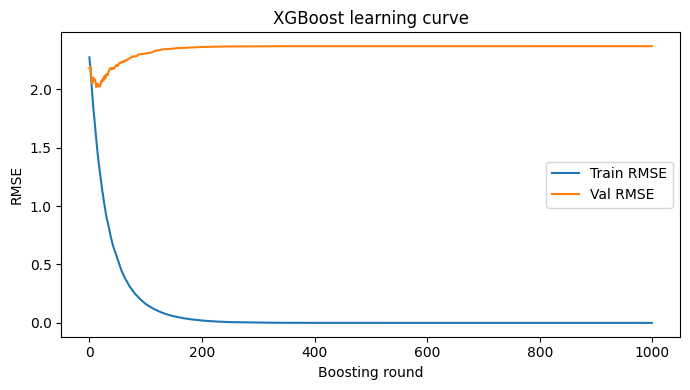

Held-out test set
MAE:  2.334
RMSE: 2.898
R2:   -0.280


In [55]:
# Learning curve with early stopping (XGBoost)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except Exception as exc:
    raise ImportError("xgboost is required for this cell. Install with: pip install xgboost") from exc

# Use combined features if available
if "X_combo" in globals() and "kept_patients_combo" in globals():
    X_use = X_combo
    kept_use = kept_patients_combo
else:
    X_use = X
    kept_use = kept_patients

# Load outcomes and get T1 pain values
outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
outcomes = pd.read_excel(outcomes_path)

pain_t1 = outcomes[outcomes["Event Name"] == "T1"].pivot_table(
    index="Patient number", values="Pain Unpleasantness", aggfunc="mean"
)
labels = pd.Series(kept_use, name="Patient").map(pain_t1["Pain Unpleasantness"])
mask = labels.notna().values
X_t1 = X_use[mask]
y_t1 = labels[mask].to_numpy(dtype=float)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_t1, y_t1, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",  # set here for older xgboost
    random_state=42,
)

# Fit with eval_set; older xgboost versions may not accept eval_metric in fit()
try:
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
        early_stopping_rounds=50,
    )
except TypeError:
    # Fallback if early_stopping_rounds is unsupported
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )

# Plot learning curve if available
if hasattr(model, "evals_result"):
    evals = model.evals_result()
    train_rmse = evals.get("validation_0", {}).get("rmse", [])
    val_rmse = evals.get("validation_1", {}).get("rmse", [])
    plt.figure(figsize=(7, 4))
    plt.plot(train_rmse, label="Train RMSE")
    plt.plot(val_rmse, label="Val RMSE")
    plt.xlabel("Boosting round")
    plt.ylabel("RMSE")
    plt.title("XGBoost learning curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Evaluate on held-out test set
preds_test = model.predict(X_test)
print("Held-out test set")
print(f"MAE:  {mean_absolute_error(y_test, preds_test):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds_test)):.3f}")
print(f"R2:   {r2_score(y_test, preds_test):.3f}")


In [51]:
# Hyperparameter search (RandomizedSearchCV) for XGBoost
import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except Exception as exc:
    raise ImportError("xgboost is required for this cell. Install with: pip install xgboost") from exc

# Use combined features if available
if "X_combo" in globals() and "kept_patients_combo" in globals():
    X_use = X_combo
    kept_use = kept_patients_combo
else:
    X_use = X
    kept_use = kept_patients

# Load outcomes and get T1 pain values
outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
outcomes = pd.read_excel(outcomes_path)

pain_t1 = outcomes[outcomes["Event Name"] == "T1"].pivot_table(
    index="Patient number", values="Pain Unpleasantness", aggfunc="mean"
)
labels = pd.Series(kept_use, name="Patient").map(pain_t1["Pain Unpleasantness"])
mask = labels.notna().values
X_t1 = X_use[mask]
y_t1 = labels[mask].to_numpy(dtype=float)

# Hold-out test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_t1, y_t1, test_size=0.2, random_state=42
)

param_distributions = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [0.5, 1.0, 2.0],
}

base_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_full, y_train_full)
print("Best params:", search.best_params_)
print(f"Best CV MAE: {-search.best_score_:.3f}")

# Evaluate best model on held-out test set
best_model = search.best_estimator_
preds_test = best_model.predict(X_test)
print("Held-out test set")
print(f"MAE:  {mean_absolute_error(y_test, preds_test):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds_test)):.3f}")
print(f"R2:   {r2_score(y_test, preds_test):.3f}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV MAE: 1.952
Held-out test set
MAE:  2.122
RMSE: 2.732
R2:   -0.137


In [ ]:
# Iterative feature elimination per sheet (band-level)
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

try:
    from xgboost import XGBRegressor
except Exception as exc:
    raise ImportError("xgboost is required for this cell. Install with: pip install xgboost") from exc

# Sheets to evaluate (edit list)
sheets_to_eval = [
    "Z_FFT_Coherence",
    "Z_FFT_PhaseLag_PLI",
    "Z_FFT_abs_bandpower_uV2",
    "Z_FFT_rel_bandpower_pct",
]

# XGBoost baseline params (tune as needed)
base_params = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
)

# Load outcomes and T1 labels
outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
outcomes = pd.read_excel(outcomes_path)

pain_t1 = outcomes[outcomes["Event Name"] == "T1"].pivot_table(
    index="Patient number", values="Pain Unpleasantness", aggfunc="mean"
)

# Build band-level feature matrix for a sheet
# Features per band: mean, median, std across rows (channels)
# Returns X (n_samples x (n_bands*3)), y (n_samples,), bands list

def build_band_features_for_sheet(sheet_name: str):
    patient_ids = build_patient_map(output_dir)
    patient_nums = list(patient_ids.keys())

    rows = []
    labels = []
    kept = []
    bands = None

    for pid in patient_nums:
        path = patient_ids.get(pid)
        if path is None:
            continue
        try:
            df = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
            numeric = df.select_dtypes(include="number").replace([np.inf, -np.inf], np.nan)
            if numeric.empty:
                continue
            if bands is None:
                bands = numeric.columns.tolist()
            # Ensure consistent band order across patients
            numeric = numeric.reindex(columns=bands)
            stats = []
            for col in bands:
                vals = numeric[col].to_numpy(dtype=float)
                vals = vals[~np.isnan(vals)]
                if vals.size == 0:
                    stats.extend([np.nan, np.nan, np.nan])
                else:
                    stats.extend([vals.mean(), np.median(vals), vals.std()])
            rows.append(stats)
            kept.append(pid)
        except Exception as exc:
            print(f"Warning: {sheet_name} patient {pid} failed: {exc}")

    if not rows:
        return None, None, None

    X = np.array(rows, dtype=float)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    y = pd.Series(kept, name="Patient").map(pain_t1["Pain Unpleasantness"])
    mask = y.notna().values
    X = X[mask]
    y = y[mask].to_numpy(dtype=float)
    kept = [pid for pid, ok in zip(kept, mask) if ok]
    return X, y, bands

# Evaluate R2 with KFold

def cv_r2(X, y, params, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr, te in kf.split(X):
        model = XGBRegressor(**params)
        model.fit(X[tr], y[tr])
        preds = model.predict(X[te])
        scores.append(r2_score(y[te], preds))
    return float(np.mean(scores)), float(np.std(scores))

# Iterative elimination
results_by_sheet = {}

for sheet in sheets_to_eval:
    X, y, bands = build_band_features_for_sheet(sheet)
    if X is None:
        print(f"Skipping {sheet}: no data")
        continue

    current_bands = bands.copy()
    history = []

    while len(current_bands) >= 1:
        # Build X for current bands
        idx = []
        for i, band in enumerate(bands):
            if band in current_bands:
                # each band contributes 3 columns: mean, median, std
                idx.extend([3 * i, 3 * i + 1, 3 * i + 2])
        X_sub = X[:, idx]

        r2_mean, r2_std = cv_r2(X_sub, y, base_params)
        history.append({
            "n_bands": len(current_bands),
            "bands": current_bands.copy(),
            "r2_mean": r2_mean,
            "r2_std": r2_std,
        })

        if len(current_bands) == 1:
            break

        # Train once to get band importances, then drop the weakest band
        model = XGBRegressor(**base_params)
        model.fit(X_sub, y)
        importances = model.feature_importances_

        # Aggregate per band (sum of 3 features per band)
        band_scores = {}
        for i, band in enumerate(bands):
            if band not in current_bands:
                continue
            band_idx = [3 * i, 3 * i + 1, 3 * i + 2]
            band_scores[band] = float(importances[[idx.index(j) for j in band_idx]].sum())

        worst_band = min(band_scores, key=band_scores.get)
        current_bands.remove(worst_band)

    # Store and report best
    best = max(history, key=lambda h: h["r2_mean"])
    results_by_sheet[sheet] = {
        "best_r2": best["r2_mean"],
        "best_r2_std": best["r2_std"],
        "best_bands": best["bands"],
        "history": history,
    }
    print(f"\n{sheet}")
    print(f"  Best R2: {best['r2_mean']:.3f} ± {best['r2_std']:.3f}")
    print(f"  Best bands: {best['bands']}")

# Top 3 sheets by best R2
sorted_sheets = sorted(results_by_sheet.items(), key=lambda x: x[1]["best_r2"], reverse=True)
print("\nTop 3 sheets by R2:")
for sheet, info in sorted_sheets[:3]:
    print(f"  {sheet}: R2={info['best_r2']:.3f} ± {info['best_r2_std']:.3f}")



Z_FFT_Coherence
  Best R2: -0.019 ± 0.223
  Best bands: ['HighBeta', 'Alpha1', 'Alpha2', 'Beta2', 'Beta3']

Z_FFT_PhaseLag_PLI
  Best R2: -0.245 ± 0.379
  Best bands: ['Theta', 'Beta', 'HighBeta', 'Alpha2', 'Beta1', 'Beta2', 'Beta3']


In [57]:
# Train XGB regressor using best sheets + best bands
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except Exception as exc:
    raise ImportError("xgboost is required for this cell. Install with: pip install xgboost") from exc

if "results_by_sheet" not in globals():
    raise RuntimeError("Run the feature elimination cell first to populate results_by_sheet.")

# Select top 3 sheets by best R2
sorted_sheets = sorted(results_by_sheet.items(), key=lambda x: x[1]["best_r2"], reverse=True)
top_sheets = [s for s, _ in sorted_sheets[:3]]
print("Top sheets:", top_sheets)

# Build combined feature matrix using the best bands from each top sheet
patient_ids = build_patient_map(output_dir)
patient_nums = list(patient_ids.keys())

X_blocks = []
kept_sets = []

for sheet in top_sheets:
    best_bands = results_by_sheet[sheet]["best_bands"]
    X_sheet, kept, all_bands = None, None, None

    # Rebuild full band-feature matrix for this sheet
    X_full, y_tmp, all_bands = None, None, None
    X_full, y_tmp, all_bands = build_band_features_for_sheet(sheet)
    if X_full is None:
        print(f"Skipping {sheet}: no data")
        continue

    # Filter to best bands (3 features per band: mean/median/std)
    idx = []
    for i, band in enumerate(all_bands):
        if band in best_bands:
            idx.extend([3 * i, 3 * i + 1, 3 * i + 2])
    X_blocks.append(X_full[:, idx])
    kept_sets.append(True)

if not X_blocks:
    raise RuntimeError("No data available for selected sheets.")

# Align labels using the same patient order as build_band_features_for_sheet
# (build_band_features_for_sheet already aligns and returns X/y in patient order)
X_combo = np.hstack(X_blocks)

# Labels are same for all sheets (use one build to get y_t1)
_, y_t1, _ = build_band_features_for_sheet(top_sheets[0])

print("Combined feature shape:", X_combo.shape)
print("Labels length:", len(y_t1))

# Train/val/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_combo, y_t1, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# Train with early stopping
model = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
)

try:
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
        early_stopping_rounds=50,
    )
except TypeError:
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )

# Evaluate on test set
preds_test = model.predict(X_test)
print("Held-out test set")
print(f"MAE:  {mean_absolute_error(y_test, preds_test):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds_test)):.3f}")
print(f"R2:   {r2_score(y_test, preds_test):.3f}")


Top sheets: ['Z_FFT_Coherence', 'Z_FFT_PhaseLag_PLI']
Combined feature shape: (78, 36)
Labels length: 78
Held-out test set
MAE:  1.702
RMSE: 1.995
R2:   -0.518


In [60]:
# Regressor with iterative band elimination across all sheets (T1 pain score)
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    REGRESSOR_NAME = "XGBoost"
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    REGRESSOR_NAME = "RandomForest"

# Sheets to evaluate (edit list)
sheets_to_eval = [
    "Z_FFT_Coherence",
    "Z_FFT_PhaseLag_PLI",
    "Z_FFT_abs_bandpower_uV2",
]

# Build band-level features + labels (T1 regression)
# Features per band: mean, median, std across channels

def build_band_features_for_sheet_with_patients(sheet_name: str):
    patient_ids = build_patient_map(output_dir)
    patient_nums = list(patient_ids.keys())

    rows = []
    kept = []
    bands = None

    for pid in patient_nums:
        path = patient_ids.get(pid)
        if path is None:
            continue
        try:
            df = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
            numeric = df.select_dtypes(include="number").replace([np.inf, -np.inf], np.nan)
            if numeric.empty:
                continue
            if bands is None:
                bands = numeric.columns.tolist()
            numeric = numeric.reindex(columns=bands)

            stats = []
            for col in bands:
                vals = numeric[col].to_numpy(dtype=float)
                vals = vals[~np.isnan(vals)]
                if vals.size == 0:
                    stats.extend([np.nan, np.nan, np.nan])
                else:
                    stats.extend([vals.mean(), np.median(vals), vals.std()])
            rows.append(stats)
            kept.append(pid)
        except Exception as exc:
            print(f"Warning: {sheet_name} patient {pid} failed: {exc}")

    if not rows:
        return None, None, None, None

    X = np.array(rows, dtype=float)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    # Labels from T1 pain
    outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
    outcomes = pd.read_excel(outcomes_path)
    pain_t1 = outcomes[outcomes["Event Name"] == "T1"].pivot_table(
        index="Patient number", values="Pain Unpleasantness", aggfunc="mean"
    )

    y = pd.Series(kept, name="Patient").map(pain_t1["Pain Unpleasantness"])
    mask = y.notna().values
    X = X[mask]
    y = y[mask].to_numpy(dtype=float)
    kept = [pid for pid, ok in zip(kept, mask) if ok]

    return X, y, bands, kept

# Regressor factory

def make_regressor():
    if REGRESSOR_NAME == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
        )
    return RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )

# CV evaluation + importance aggregation

def cv_scores_and_importance(X, y, band_to_positions):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    rmse_scores = []
    r2_scores = []
    importances = []

    for tr, te in kf.split(X):
        reg = make_regressor()
        reg.fit(X[tr], y[tr])
        preds = reg.predict(X[te])
        mae_scores.append(mean_absolute_error(y[te], preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y[te], preds)))
        r2_scores.append(r2_score(y[te], preds))

        if hasattr(reg, "feature_importances_"):
            importances.append(reg.feature_importances_)

    mean_mae = float(np.mean(mae_scores))
    mean_rmse = float(np.mean(rmse_scores))
    mean_r2 = float(np.mean(r2_scores))

    band_importance = None
    if importances:
        avg_importance = np.mean(importances, axis=0)
        band_importance = {
            band: float(avg_importance[pos].sum())
            for band, pos in band_to_positions.items()
        }

    return mean_mae, mean_rmse, mean_r2, band_importance

# Iterative elimination per sheet
results_by_sheet_reg = {}

for sheet in sheets_to_eval:
    X, y, bands, kept = build_band_features_for_sheet_with_patients(sheet)
    if X is None:
        print(f"Skipping {sheet}: no data")
        continue

    current_bands = bands.copy()
    history = []

    while len(current_bands) >= 1:
        # Build indices for current bands
        band_to_positions = {}
        idx = []
        for i, band in enumerate(bands):
            if band in current_bands:
                pos = [len(idx), len(idx) + 1, len(idx) + 2]
                band_to_positions[band] = pos
                idx.extend([3 * i, 3 * i + 1, 3 * i + 2])

        X_sub = X[:, idx]

        mae, rmse, r2, band_importance = cv_scores_and_importance(X_sub, y, band_to_positions)
        history.append({
            "n_bands": len(current_bands),
            "bands": current_bands.copy(),
            "mae_mean": mae,
            "rmse_mean": rmse,
            "r2_mean": r2,
        })

        if len(current_bands) == 1:
            break

        # Drop weakest band by average importance across CV folds
        if band_importance is None:
            break
        worst_band = min(band_importance, key=band_importance.get)
        current_bands.remove(worst_band)

    # Choose best by lowest RMSE (tie-breaker: lowest MAE)
    best = sorted(history, key=lambda h: (h["rmse_mean"], h["mae_mean"]))[0]
    results_by_sheet_reg[sheet] = {
        "best_rmse": best["rmse_mean"],
        "best_mae": best["mae_mean"],
        "best_r2": best["r2_mean"],
        "best_bands": best["bands"],
        "history": history,
    }
    print(f"\n{sheet}")
    print(f"  Best RMSE: {best['rmse_mean']:.3f}")
    print(f"  Best MAE:  {best['mae_mean']:.3f}")
    print(f"  Best R2:   {best['r2_mean']:.3f}")
    print(f"  Best bands: {best['bands']}")

# Top sheets by lowest RMSE
sorted_sheets = sorted(results_by_sheet_reg.items(), key=lambda x: x[1]["best_rmse"])
print("\nTop 3 sheets by RMSE:")
for sheet, info in sorted_sheets[:3]:
    print(f"  {sheet}: RMSE={info['best_rmse']:.3f}, MAE={info['best_mae']:.3f}, R2={info['best_r2']:.3f}")

# Combine top sheets and run 5-fold CV (no leakage)

def build_combined_Xy(top_sheets):
    per_sheet = {}
    common = None

    for sheet in top_sheets:
        Xs, ys, bands, kept = build_band_features_for_sheet_with_patients(sheet)
        best_bands = results_by_sheet_reg[sheet]["best_bands"]

        # Filter to best bands
        idx = []
        for i, band in enumerate(bands):
            if band in best_bands:
                idx.extend([3 * i, 3 * i + 1, 3 * i + 2])
        Xs = Xs[:, idx]

        feats_by_patient = {pid: Xs[i] for i, pid in enumerate(kept)}
        per_sheet[sheet] = (feats_by_patient, ys, kept)

        if common is None:
            common = set(kept)
        else:
            common &= set(kept)

    common = sorted(common)
    X_blocks = []
    y_final = None

    for sheet in top_sheets:
        feats_by_patient, ys, kept = per_sheet[sheet]
        X_blocks.append(np.vstack([feats_by_patient[pid] for pid in common]))
        if y_final is None:
            # Recompute y on common patients for consistency
            _, y_reg, _, kept_all = build_band_features_for_sheet_with_patients(sheet)
            mapping = {pid: y_reg[i] for i, pid in enumerate(kept_all)}
            y_final = np.array([mapping[pid] for pid in common], dtype=float)

    X_combo = np.hstack(X_blocks)
    return X_combo, y_final

if sorted_sheets:
    top_sheets = [s for s, _ in sorted_sheets[:3]]
    X_combo, y_combo = build_combined_Xy(top_sheets)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    rmse_scores = []
    r2_scores = []

    for tr, te in kf.split(X_combo):
        reg = make_regressor()
        reg.fit(X_combo[tr], y_combo[tr])
        preds = reg.predict(X_combo[te])
        mae_scores.append(mean_absolute_error(y_combo[te], preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_combo[te], preds)))
        r2_scores.append(r2_score(y_combo[te], preds))

    print("\nCombined top sheets (5-fold CV)")
    print(f"MAE:  {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
    print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
    print(f"R2:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")



Z_FFT_Coherence
  Best RMSE: 2.304
  Best MAE:  1.877
  Best R2:   -0.105
  Best bands: ['HighBeta', 'Alpha1', 'Alpha2', 'Beta1', 'Beta2', 'Beta3']


KeyboardInterrupt: 

In [62]:
# ALL sheets + raw features (no summary stats): elimination + T1 regression
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    REGRESSOR_NAME = "XGBoost"
except Exception:
    from sklearn.ensemble import RandomForestRegressor
    REGRESSOR_NAME = "RandomForest"

# Load outcomes and T1 labels once
outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
outcomes = pd.read_excel(outcomes_path)
pain_t1 = outcomes[outcomes["Event Name"] == "T1"].pivot_table(
    index="Patient number", values="Pain Unpleasantness", aggfunc="mean"
)

# Regressor factory

def make_regressor():
    if REGRESSOR_NAME == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
        )
    return RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )

# Get ALL sheet names from all patients

def get_all_sheet_names(patient_ids: dict):
    all_sheets = set()
    for pid, path in patient_ids.items():
        try:
            xls = pd.ExcelFile(path)
            all_sheets.update(xls.sheet_names)
        except Exception:
            continue
    # skip non-feature sheets
    all_sheets = [s for s in all_sheets if s.lower() not in {"meta"}]
    return sorted(all_sheets)

# Build raw flattened features per sheet (consistent shape only)

def build_raw_features_for_sheet(sheet_name: str):
    patient_ids = build_patient_map(output_dir)
    patient_nums = list(patient_ids.keys())

    rows = []
    kept = []
    template_shape = None

    for pid in patient_nums:
        path = patient_ids.get(pid)
        if path is None:
            continue
        try:
            df = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
            numeric = df.select_dtypes(include="number").replace([np.inf, -np.inf], np.nan)
            if numeric.empty:
                continue

            if template_shape is None:
                template_shape = numeric.shape
            if numeric.shape != template_shape:
                # Skip inconsistent shapes to avoid misalignment
                continue

            vec = numeric.to_numpy(dtype=float).flatten()
            vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)
            rows.append(vec)
            kept.append(pid)
        except Exception as exc:
            print(f"Warning: {sheet_name} patient {pid} failed: {exc}")

    if not rows:
        return None, None, None

    X = np.vstack(rows)
    y = pd.Series(kept, name="Patient").map(pain_t1["Pain Unpleasantness"])
    mask = y.notna().values
    X = X[mask]
    y = y[mask].to_numpy(dtype=float)
    kept = [pid for pid, ok in zip(kept, mask) if ok]

    return X, y, kept

# CV evaluation + importance aggregation

def cv_scores_and_importance(X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    rmse_scores = []
    r2_scores = []
    importances = []

    for tr, te in kf.split(X):
        reg = make_regressor()
        reg.fit(X[tr], y[tr])
        preds = reg.predict(X[te])
        mae_scores.append(mean_absolute_error(y[te], preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y[te], preds)))
        r2_scores.append(r2_score(y[te], preds))

        if hasattr(reg, "feature_importances_"):
            importances.append(reg.feature_importances_)

    mean_mae = float(np.mean(mae_scores))
    mean_rmse = float(np.mean(rmse_scores))
    mean_r2 = float(np.mean(r2_scores))

    avg_importance = None
    if importances:
        avg_importance = np.mean(importances, axis=0)

    return mean_mae, mean_rmse, mean_r2, avg_importance

# Iterative elimination per sheet (drop lowest-importance raw features)
results_by_sheet_raw = {}
patient_ids = build_patient_map(output_dir)
all_sheets = get_all_sheet_names(patient_ids)

for sheet in all_sheets:
    X, y, kept = build_raw_features_for_sheet(sheet)
    if X is None:
        print(f"Skipping {sheet}: no data")
        continue

    current_idx = list(range(X.shape[1]))
    history = []

    # limit iterations to avoid extremely long runtimes
    max_steps = min(20, max(1, len(current_idx) // 10))

    for _ in range(max_steps):
        X_sub = X[:, current_idx]
        mae, rmse, r2, avg_importance = cv_scores_and_importance(X_sub, y)
        history.append({
            "n_features": len(current_idx),
            "mae_mean": mae,
            "rmse_mean": rmse,
            "r2_mean": r2,
            "feature_idx": current_idx.copy(),
        })

        if avg_importance is None or len(current_idx) <= 5:
            break

        # Drop bottom 10% of features each step
        n_drop = max(1, len(current_idx) // 10)
        drop_idx = np.argsort(avg_importance)[:n_drop]
        current_idx = [c for i, c in enumerate(current_idx) if i not in drop_idx]

    best = sorted(history, key=lambda h: (h["rmse_mean"], h["mae_mean"]))[0]
    results_by_sheet_raw[sheet] = {
        "best_rmse": best["rmse_mean"],
        "best_mae": best["mae_mean"],
        "best_r2": best["r2_mean"],
        "best_feature_count": best["n_features"],
        "best_feature_idx": best["feature_idx"],
        "history": history,
    }
    print(f"\n{sheet}")
    print(f"  Best RMSE: {best['rmse_mean']:.3f}")
    print(f"  Best MAE:  {best['mae_mean']:.3f}")
    print(f"  Best R2:   {best['r2_mean']:.3f}")
    print(f"  Best feature count: {best['n_features']}")

# Top sheets by lowest RMSE
sorted_sheets = sorted(results_by_sheet_raw.items(), key=lambda x: x[1]["best_rmse"])
print("\nTop 3 sheets by RMSE:")
for sheet, info in sorted_sheets[:3]:
    print(f"  {sheet}: RMSE={info['best_rmse']:.3f}, MAE={info['best_mae']:.3f}, R2={info['best_r2']:.3f}")

# Combine top sheets using their best feature indices, then run 5-fold CV

def build_combined_Xy(top_sheets):
    per_sheet = {}
    common = None

    for sheet in top_sheets:
        Xs, ys, kept = build_raw_features_for_sheet(sheet)
        best_idx = results_by_sheet_raw[sheet]["best_feature_idx"]
        Xs = Xs[:, best_idx]

        feats_by_patient = {pid: Xs[i] for i, pid in enumerate(kept)}
        per_sheet[sheet] = (feats_by_patient, ys, kept)

        if common is None:
            common = set(kept)
        else:
            common &= set(kept)

    common = sorted(common)
    X_blocks = []
    y_final = None

    for sheet in top_sheets:
        feats_by_patient, ys, kept = per_sheet[sheet]
        X_blocks.append(np.vstack([feats_by_patient[pid] for pid in common]))
        if y_final is None:
            mapping = {pid: ys[i] for i, pid in enumerate(kept)}
            y_final = np.array([mapping[pid] for pid in common], dtype=float)

    X_combo = np.hstack(X_blocks)
    return X_combo, y_final

if sorted_sheets:
    top_sheets = [s for s, _ in sorted_sheets[:3]]
    X_combo, y_combo = build_combined_Xy(top_sheets)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_scores = []
    rmse_scores = []
    r2_scores = []

    for tr, te in kf.split(X_combo):
        reg = make_regressor()
        reg.fit(X_combo[tr], y_combo[tr])
        preds = reg.predict(X_combo[te])
        mae_scores.append(mean_absolute_error(y_combo[te], preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_combo[te], preds)))
        r2_scores.append(r2_score(y_combo[te], preds))

    print("\nCombined top sheets (5-fold CV)")
    print(f"MAE:  {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
    print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
    print(f"R2:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")



FFT_Coherence
  Best RMSE: 2.137
  Best MAE:  1.800
  Best R2:   0.038
  Best feature count: 235

FFT_PhaseLag_PLI
  Best RMSE: 2.204
  Best MAE:  1.845
  Best R2:   -0.001
  Best feature count: 321

FFT_abs_1to50Hz_uV2
  Best RMSE: 2.281
  Best MAE:  1.982
  Best R2:   -0.118
  Best feature count: 146

FFT_abs_bandpower_uV2
  Best RMSE: 2.241
  Best MAE:  1.908
  Best R2:   -0.104
  Best feature count: 41

FFT_rel_1to50Hz_pct
  Best RMSE: 2.523
  Best MAE:  2.085
  Best R2:   -0.294
  Best feature count: 146

FFT_rel_bandpower_pct
  Best RMSE: 2.513
  Best MAE:  2.103
  Best R2:   -0.328
  Best feature count: 41

PeakFreq_Hz
  Best RMSE: 2.252
  Best MAE:  1.889
  Best R2:   -0.046
  Best feature count: 41

Z_FFT_Coherence
  Best RMSE: 2.126
  Best MAE:  1.763
  Best R2:   0.047
  Best feature count: 261

Z_FFT_PhaseLag_PLI
  Best RMSE: 2.211
  Best MAE:  1.807
  Best R2:   -0.035
  Best feature count: 235

Z_FFT_abs_1to30Hz_uV2
  Best RMSE: 2.203
  Best MAE:  1.845
  Best R2:   -0.0

In [63]:
# Predict T2-T1 (Diff) from EEG features: regression or classification
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
except Exception:
    from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
    HAS_XGB = False

# -------------------------
# Labels: T2 - T1 Diff
# -------------------------

def get_diff_labels():
    outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
    outcomes = pd.read_excel(outcomes_path)
    diff = outcomes[outcomes["Event Name"].isin(["T1", "T2"])].pivot_table(
        index="Patient number", columns="Event Name", values="Pain Unpleasantness"
    ).dropna()
    diff["Diff"] = diff["T2"] - diff["T1"]
    return diff["Diff"]

# -------------------------
# Features: raw flattened per sheet (consistent shape only)
# -------------------------

def get_all_sheet_names(patient_ids: dict):
    all_sheets = set()
    for pid, path in patient_ids.items():
        try:
            xls = pd.ExcelFile(path)
            all_sheets.update(xls.sheet_names)
        except Exception:
            continue
    all_sheets = [s for s in all_sheets if s.lower() not in {"meta"}]
    return sorted(all_sheets)


def build_raw_features_for_sheet(sheet_name: str, diff_labels: pd.Series):
    patient_ids = build_patient_map(output_dir)
    patient_nums = list(patient_ids.keys())

    rows = []
    kept = []
    template_shape = None

    for pid in patient_nums:
        path = patient_ids.get(pid)
        if path is None:
            continue
        try:
            df = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
            numeric = df.select_dtypes(include="number").replace([np.inf, -np.inf], np.nan)
            if numeric.empty:
                continue

            if template_shape is None:
                template_shape = numeric.shape
            if numeric.shape != template_shape:
                continue

            vec = numeric.to_numpy(dtype=float).flatten()
            vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)
            rows.append(vec)
            kept.append(pid)
        except Exception:
            continue

    if not rows:
        return None, None, None

    X = np.vstack(rows)
    y = pd.Series(kept, name="Patient").map(diff_labels)
    mask = y.notna().values
    X = X[mask]
    y = y[mask].to_numpy(dtype=float)
    kept = [pid for pid, ok in zip(kept, mask) if ok]

    return X, y, kept


def build_combined_features(sheets, diff_labels):
    per_sheet = {}
    common = None

    for sheet in sheets:
        Xs, ys, kept = build_raw_features_for_sheet(sheet, diff_labels)
        if Xs is None:
            continue
        feats_by_patient = {pid: Xs[i] for i, pid in enumerate(kept)}
        per_sheet[sheet] = (feats_by_patient, ys, kept)

        if common is None:
            common = set(kept)
        else:
            common &= set(kept)

    if not per_sheet or not common:
        return None, None

    common = sorted(common)
    X_blocks = []
    y_final = None

    for sheet in sheets:
        if sheet not in per_sheet:
            continue
        feats_by_patient, ys, kept = per_sheet[sheet]
        X_blocks.append(np.vstack([feats_by_patient[pid] for pid in common]))
        if y_final is None:
            mapping = {pid: ys[i] for i, pid in enumerate(kept)}
            y_final = np.array([mapping[pid] for pid in common], dtype=float)

    X_combo = np.hstack(X_blocks)
    return X_combo, y_final

# -------------------------
# Model factories
# -------------------------

def make_regressor():
    if HAS_XGB:
        return XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
        )
    return RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )


def make_classifier():
    if HAS_XGB:
        return XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            use_label_encoder=False,
        )
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )

# -------------------------
# Main method
# -------------------------

def run_diff_prediction(mode="regression", top_k=3):
    diff_labels = get_diff_labels()
    patient_ids = build_patient_map(output_dir)
    all_sheets = get_all_sheet_names(patient_ids)

    # Rank sheets individually if top_k specified
    sheet_scores = []
    for sheet in all_sheets:
        X, y, _ = build_raw_features_for_sheet(sheet, diff_labels)
        if X is None:
            continue

        if mode == "regression":
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            rmse_list = []
            for tr, te in kf.split(X):
                reg = make_regressor()
                reg.fit(X[tr], y[tr])
                preds = reg.predict(X[te])
                rmse_list.append(np.sqrt(mean_squared_error(y[te], preds)))
            score = float(np.mean(rmse_list))
            sheet_scores.append((sheet, score))
        else:
            # classification: median split of Diff
            y_class = (y >= np.median(y)).astype(int)
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            acc_list = []
            for tr, te in skf.split(X, y_class):
                clf = make_classifier()
                clf.fit(X[tr], y_class[tr])
                preds = clf.predict(X[te])
                acc_list.append(accuracy_score(y_class[te], preds))
            score = float(np.mean(acc_list))
            sheet_scores.append((sheet, score))

    if not sheet_scores:
        raise RuntimeError("No usable sheets found.")

    if mode == "regression":
        sheet_scores.sort(key=lambda x: x[1])  # lower RMSE is better
    else:
        sheet_scores.sort(key=lambda x: x[1], reverse=True)  # higher ACC is better

    selected_sheets = [s for s, _ in sheet_scores[:top_k]]
    print(f"Selected sheets ({mode}):", selected_sheets)

    X_combo, y_combo = build_combined_features(selected_sheets, diff_labels)
    if X_combo is None:
        raise RuntimeError("Failed to build combined features.")

    if mode == "regression":
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        mae_scores, rmse_scores, r2_scores = [], [], []
        for tr, te in kf.split(X_combo):
            reg = make_regressor()
            reg.fit(X_combo[tr], y_combo[tr])
            preds = reg.predict(X_combo[te])
            mae_scores.append(mean_absolute_error(y_combo[te], preds))
            rmse_scores.append(np.sqrt(mean_squared_error(y_combo[te], preds)))
            r2_scores.append(r2_score(y_combo[te], preds))

        print("\nT2-T1 Diff Regression (5-fold CV)")
        print(f"MAE:  {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
        print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
        print(f"R2:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
    else:
        y_class = (y_combo >= np.median(y_combo)).astype(int)
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        acc_scores, auc_scores = [], []

        for tr, te in skf.split(X_combo, y_class):
            clf = make_classifier()
            clf.fit(X_combo[tr], y_class[tr])
            preds = clf.predict(X_combo[te])
            acc_scores.append(accuracy_score(y_class[te], preds))

            if hasattr(clf, "predict_proba"):
                probs = clf.predict_proba(X_combo[te])[:, 1]
                try:
                    auc_scores.append(roc_auc_score(y_class[te], probs))
                except Exception:
                    pass

        print("\nT2-T1 Diff Classification (5-fold CV)")
        print(f"ACC: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}")
        if auc_scores:
            print(f"AUC: {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")

# Example runs
run_diff_prediction(mode="regression", top_k=3)
# run_diff_prediction(mode="classification", top_k=3)


Selected sheets (regression): ['Z_FFT_rel_1to30Hz_pct', 'Z_FFT_rel_bandpower_pct', 'FFT_PhaseLag_PLI']

T2-T1 Diff Regression (5-fold CV)
MAE:  1.835 ± 0.439
RMSE: 2.254 ± 0.609
R2:   -0.531 ± 0.479


In [64]:
# Improve T2-T1 Diff prediction: scaling, outlier filtering, XGB tuning, and simpler models
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, ElasticNet

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ---- Settings ----
mode_top_k = 3
outlier_sigma = 3.0  # set to None to disable
random_state = 42

# ---- Labels ----

def get_diff_labels():
    outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
    outcomes = pd.read_excel(outcomes_path)
    diff = outcomes[outcomes["Event Name"].isin(["T1", "T2"])].pivot_table(
        index="Patient number", columns="Event Name", values="Pain Unpleasantness"
    ).dropna()
    diff["Diff"] = diff["T2"] - diff["T1"]
    return diff["Diff"]

# ---- Features: raw flattened per sheet ----

def get_all_sheet_names(patient_ids: dict):
    all_sheets = set()
    for pid, path in patient_ids.items():
        try:
            xls = pd.ExcelFile(path)
            all_sheets.update(xls.sheet_names)
        except Exception:
            continue
    return sorted([s for s in all_sheets if s.lower() not in {"meta"}])


def build_raw_features_for_sheet(sheet_name: str, diff_labels: pd.Series):
    patient_ids = build_patient_map(output_dir)
    patient_nums = list(patient_ids.keys())

    rows = []
    kept = []
    template_shape = None

    for pid in patient_nums:
        path = patient_ids.get(pid)
        if path is None:
            continue
        try:
            df = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
            numeric = df.select_dtypes(include="number").replace([np.inf, -np.inf], np.nan)
            if numeric.empty:
                continue

            if template_shape is None:
                template_shape = numeric.shape
            if numeric.shape != template_shape:
                continue

            vec = numeric.to_numpy(dtype=float).flatten()
            vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)
            rows.append(vec)
            kept.append(pid)
        except Exception:
            continue

    if not rows:
        return None, None, None

    X = np.vstack(rows)
    y = pd.Series(kept, name="Patient").map(diff_labels)
    mask = y.notna().values
    X = X[mask]
    y = y[mask].to_numpy(dtype=float)
    kept = [pid for pid, ok in zip(kept, mask) if ok]

    return X, y, kept


def build_combined_features(sheets, diff_labels):
    per_sheet = {}
    common = None

    for sheet in sheets:
        Xs, ys, kept = build_raw_features_for_sheet(sheet, diff_labels)
        if Xs is None:
            continue
        feats_by_patient = {pid: Xs[i] for i, pid in enumerate(kept)}
        per_sheet[sheet] = (feats_by_patient, ys, kept)

        if common is None:
            common = set(kept)
        else:
            common &= set(kept)

    if not per_sheet or not common:
        return None, None

    common = sorted(common)
    X_blocks = []
    y_final = None

    for sheet in sheets:
        if sheet not in per_sheet:
            continue
        feats_by_patient, ys, kept = per_sheet[sheet]
        X_blocks.append(np.vstack([feats_by_patient[pid] for pid in common]))
        if y_final is None:
            mapping = {pid: ys[i] for i, pid in enumerate(kept)}
            y_final = np.array([mapping[pid] for pid in common], dtype=float)

    X_combo = np.hstack(X_blocks)
    return X_combo, y_final

# ---- Rank sheets by RMSE (5-fold CV) ----

def rank_sheets(diff_labels):
    patient_ids = build_patient_map(output_dir)
    all_sheets = get_all_sheet_names(patient_ids)
    scores = []
    for sheet in all_sheets:
        X, y, _ = build_raw_features_for_sheet(sheet, diff_labels)
        if X is None:
            continue
        kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
        rmse_list = []
        for tr, te in kf.split(X):
            reg = Ridge(alpha=1.0)
            reg.fit(X[tr], y[tr])
            preds = reg.predict(X[te])
            rmse_list.append(np.sqrt(mean_squared_error(y[te], preds)))
        scores.append((sheet, float(np.mean(rmse_list))))
    scores.sort(key=lambda x: x[1])
    return scores

# ---- Build combined dataset ----

diff_labels = get_diff_labels()
ranked = rank_sheets(diff_labels)
selected_sheets = [s for s, _ in ranked[:mode_top_k]]
print("Selected sheets:", selected_sheets)

X_combo, y_combo = build_combined_features(selected_sheets, diff_labels)
if X_combo is None:
    raise RuntimeError("Failed to build combined features.")

# ---- Optional outlier filtering on y ----
if outlier_sigma is not None:
    mu, sigma = np.mean(y_combo), np.std(y_combo)
    keep_mask = np.abs(y_combo - mu) <= outlier_sigma * sigma
    X_combo = X_combo[keep_mask]
    y_combo = y_combo[keep_mask]
    print(f"After outlier filter (±{outlier_sigma}σ): n={len(y_combo)}")

# ---- 5-fold CV: baseline Ridge + ElasticNet (simpler models) ----
print("\nSimpler models (5-fold CV)")
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

for name, model in [
    ("Ridge", Ridge(alpha=1.0)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=random_state)),
]:
    mae_scores, rmse_scores, r2_scores = [], [], []
    for tr, te in kf.split(X_combo):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model),
        ])
        pipe.fit(X_combo[tr], y_combo[tr])
        preds = pipe.predict(X_combo[te])
        mae_scores.append(mean_absolute_error(y_combo[te], preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_combo[te], preds)))
        r2_scores.append(r2_score(y_combo[te], preds))
    print(f"{name} MAE:  {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
    print(f"{name} RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
    print(f"{name} R2:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}\n")

# ---- XGBoost with scaling + randomized search + early stopping ----
if HAS_XGB:
    print("XGBoost tuned (5-fold CV on train split)")
    X_train, X_test, y_train, y_test = train_test_split(
        X_combo, y_combo, test_size=0.2, random_state=random_state
    )

    param_dist = {
        "n_estimators": [200, 400, 600, 800],
        "max_depth": [2, 3, 4, 5, 6],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5, 7],
        "reg_alpha": [0.0, 0.1, 0.5],
        "reg_lambda": [0.5, 1.0, 2.0],
    }

    base = XGBRegressor(
        objective="reg:squarederror",
        random_state=random_state,
        eval_metric="rmse",
    )

    search = RandomizedSearchCV(
        estimator=base,
        param_distributions=param_dist,
        n_iter=25,
        scoring="neg_mean_squared_error",
        cv=5,
        random_state=random_state,
        n_jobs=-1,
        verbose=1,
    )

    # scale inside the CV loop using pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", search),
    ])

    pipe.fit(X_train, y_train)
    best_model = pipe.named_steps["model"].best_estimator_
    print("Best params:", pipe.named_steps["model"].best_params_)

    preds_test = best_model.predict(StandardScaler().fit_transform(X_test))
    print("Held-out test set")
    print(f"MAE:  {mean_absolute_error(y_test, preds_test):.3f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds_test)):.3f}")
    print(f"R2:   {r2_score(y_test, preds_test):.3f}")
else:
    print("XGBoost not available; ran only simpler models.")


Selected sheets: ['FFT_PhaseLag_PLI', 'Z_FFT_PhaseLag_PLI', 'Z_FFT_rel_1to50Hz_pct']
After outlier filter (±3.0σ): n=74

Simpler models (5-fold CV)
Ridge MAE:  1.682 ± 0.239
Ridge RMSE: 2.077 ± 0.315
Ridge R2:   -0.269 ± 0.234

ElasticNet MAE:  1.689 ± 0.209
ElasticNet RMSE: 2.083 ± 0.211
ElasticNet R2:   -0.301 ± 0.270

XGBoost tuned (5-fold CV on train split)
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Held-out test set
MAE:  1.988
RMSE: 2.495
R2:   -0.563


In [65]:
# Diff prediction upgrades: PCA/PLS, regularization, feature grouping, target transforms,
# outlier trimming, and nested CV (documented)
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# Documentation (what this cell does)
# -------------------------
print("""
This cell implements:
1) Feature grouping (per-band + per-channel summaries) instead of raw flattening.
2) Target transform (rank-normalized Diff) + inverse transform for metrics.
3) Outlier trimming (Diff outside +/- k sigma).
4) PCA + Ridge regression (small n / large p stabilization).
5) PLS regression (supervised dimension reduction).
6) Strongly regularized linear models (Ridge/Lasso/ElasticNet).
7) Nested CV: inner loop picks hyperparameters; outer loop reports honest metrics.
""")

# -------------------------
# Labels: T2-T1 Diff
# -------------------------

def get_diff_labels():
    outcomes_path = Path(output_dir) / "Randomization factors and Primary outcome.xlsx"
    outcomes = pd.read_excel(outcomes_path)
    diff = outcomes[outcomes["Event Name"].isin(["T1", "T2"])].pivot_table(
        index="Patient number", columns="Event Name", values="Pain Unpleasantness"
    ).dropna()
    diff["Diff"] = diff["T2"] - diff["T1"]
    return diff["Diff"]

# -------------------------
# Feature grouping: per-band + per-channel summaries
# -------------------------

def build_grouped_features_for_sheet(sheet_name: str, diff_labels: pd.Series):
    patient_ids = build_patient_map(output_dir)
    patient_nums = list(patient_ids.keys())

    rows = []
    kept = []
    bands = None

    for pid in patient_nums:
        path = patient_ids.get(pid)
        if path is None:
            continue
        try:
            df = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
            numeric = df.select_dtypes(include="number").replace([np.inf, -np.inf], np.nan)
            if numeric.empty:
                continue
            if bands is None:
                bands = numeric.columns.tolist()
            numeric = numeric.reindex(columns=bands)

            # Per-band stats across channels
            band_means = numeric.mean(axis=0, skipna=True).to_numpy()
            band_medians = numeric.median(axis=0, skipna=True).to_numpy()
            band_stds = numeric.std(axis=0, skipna=True).to_numpy()

            # Per-channel stats across bands
            chan_means = numeric.mean(axis=1, skipna=True).to_numpy()
            chan_medians = numeric.median(axis=1, skipna=True).to_numpy()
            chan_stds = numeric.std(axis=1, skipna=True).to_numpy()

            vec = np.concatenate([
                np.nan_to_num(band_means),
                np.nan_to_num(band_medians),
                np.nan_to_num(band_stds),
                np.nan_to_num(chan_means),
                np.nan_to_num(chan_medians),
                np.nan_to_num(chan_stds),
            ])
            rows.append(vec)
            kept.append(pid)
        except Exception:
            continue

    if not rows:
        return None, None, None

    X = np.vstack(rows)
    y = pd.Series(kept, name="Patient").map(diff_labels)
    mask = y.notna().values
    X = X[mask]
    y = y[mask].to_numpy(dtype=float)
    kept = [pid for pid, ok in zip(kept, mask) if ok]

    return X, y, kept

# -------------------------
# Target transform (rank normalize)
# -------------------------

def rank_normalize(y):
    ranks = pd.Series(y).rank(method="average").to_numpy()
    y_rank = (ranks - 1) / (len(ranks) - 1)
    return y_rank

# -------------------------
# Nested CV helpers
# -------------------------

def nested_cv_ridge_pca(X, y, alphas, n_components_list):
    outer = KFold(n_splits=5, shuffle=True, random_state=42)
    metrics = []

    for tr, te in outer.split(X):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        # inner CV to pick alpha + n_components
        best = None
        inner = KFold(n_splits=3, shuffle=True, random_state=42)
        for alpha in alphas:
            for n_comp in n_components_list:
                inner_rmse = []
                for tr2, va2 in inner.split(X_tr):
                    scaler = StandardScaler()
                    Xtr2 = scaler.fit_transform(X_tr[tr2])
                    Xva2 = scaler.transform(X_tr[va2])

                    pca = PCA(n_components=n_comp, random_state=42)
                    Xtr2p = pca.fit_transform(Xtr2)
                    Xva2p = pca.transform(Xva2)

                    model = Ridge(alpha=alpha)
                    model.fit(Xtr2p, y_tr[tr2])
                    preds = model.predict(Xva2p)
                    inner_rmse.append(np.sqrt(mean_squared_error(y_tr[va2], preds)))

                score = np.mean(inner_rmse)
                if best is None or score < best[0]:
                    best = (score, alpha, n_comp)

        # train final with best params
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X_tr)
        Xte = scaler.transform(X_te)
        pca = PCA(n_components=best[2], random_state=42)
        Xtrp = pca.fit_transform(Xtr)
        Xtep = pca.transform(Xte)
        model = Ridge(alpha=best[1])
        model.fit(Xtrp, y_tr)
        preds = model.predict(Xtep)

        metrics.append([
            mean_absolute_error(y_te, preds),
            np.sqrt(mean_squared_error(y_te, preds)),
            r2_score(y_te, preds),
        ])

    return np.mean(metrics, axis=0), np.std(metrics, axis=0)


def nested_cv_pls(X, y, n_components_list):
    outer = KFold(n_splits=5, shuffle=True, random_state=42)
    metrics = []

    for tr, te in outer.split(X):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        best = None
        inner = KFold(n_splits=3, shuffle=True, random_state=42)
        for n_comp in n_components_list:
            inner_rmse = []
            for tr2, va2 in inner.split(X_tr):
                scaler = StandardScaler()
                Xtr2 = scaler.fit_transform(X_tr[tr2])
                Xva2 = scaler.transform(X_tr[va2])

                pls = PLSRegression(n_components=n_comp)
                pls.fit(Xtr2, y_tr[tr2])
                preds = pls.predict(Xva2).ravel()
                inner_rmse.append(np.sqrt(mean_squared_error(y_tr[va2], preds)))
            score = np.mean(inner_rmse)
            if best is None or score < best[0]:
                best = (score, n_comp)

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X_tr)
        Xte = scaler.transform(X_te)
        pls = PLSRegression(n_components=best[1])
        pls.fit(Xtr, y_tr)
        preds = pls.predict(Xte).ravel()

        metrics.append([
            mean_absolute_error(y_te, preds),
            np.sqrt(mean_squared_error(y_te, preds)),
            r2_score(y_te, preds),
        ])

    return np.mean(metrics, axis=0), np.std(metrics, axis=0)


def nested_cv_regularized(X, y, model_grid):
    outer = KFold(n_splits=5, shuffle=True, random_state=42)
    metrics = []

    for tr, te in outer.split(X):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        best = None
        inner = KFold(n_splits=3, shuffle=True, random_state=42)
        for model_name, model in model_grid:
            inner_rmse = []
            for tr2, va2 in inner.split(X_tr):
                scaler = StandardScaler()
                Xtr2 = scaler.fit_transform(X_tr[tr2])
                Xva2 = scaler.transform(X_tr[va2])

                m = model
                m.fit(Xtr2, y_tr[tr2])
                preds = m.predict(Xva2)
                inner_rmse.append(np.sqrt(mean_squared_error(y_tr[va2], preds)))
            score = np.mean(inner_rmse)
            if best is None or score < best[0]:
                best = (score, model_name, model)

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X_tr)
        Xte = scaler.transform(X_te)
        best_model = best[2]
        best_model.fit(Xtr, y_tr)
        preds = best_model.predict(Xte)

        metrics.append([
            mean_absolute_error(y_te, preds),
            np.sqrt(mean_squared_error(y_te, preds)),
            r2_score(y_te, preds),
        ])

    return np.mean(metrics, axis=0), np.std(metrics, axis=0)

# -------------------------
# Run experiments
# -------------------------

diff_labels = get_diff_labels()
patient_ids = build_patient_map(output_dir)
all_sheets = [s for s in get_unique_sheet_names(patient_ids) if s.lower() != "meta"]

# Build grouped features from ALL sheets combined
X_blocks = []
common = None
per_sheet_y = None

for sheet in all_sheets:
    Xs, ys, kept = build_grouped_features_for_sheet(sheet, diff_labels)
    if Xs is None:
        continue
    feats_by_patient = {pid: Xs[i] for i, pid in enumerate(kept)}

    if common is None:
        common = set(kept)
    else:
        common &= set(kept)

    X_blocks.append((sheet, feats_by_patient, kept, ys))

if not X_blocks or not common:
    raise RuntimeError("No usable sheets for grouped features.")

common = sorted(common)

# Concatenate grouped features across sheets
X_list = []
for sheet, feats_by_patient, kept, ys in X_blocks:
    X_list.append(np.vstack([feats_by_patient[pid] for pid in common]))

X_grouped = np.hstack(X_list)

# Labels aligned to common patients
label_map = {pid: diff_labels.loc[pid] for pid in common if pid in diff_labels.index}
y = np.array([label_map[pid] for pid in common], dtype=float)

# Outlier trimming
mu, sigma = np.mean(y), np.std(y)
keep_mask = np.abs(y - mu) <= 3.0 * sigma
X_grouped = X_grouped[keep_mask]
y = y[keep_mask]

# Target transform (rank normalize)
y_rank = rank_normalize(y)

print(f"Grouped feature shape: {X_grouped.shape}")
print(f"Samples after trimming: {len(y)}")

# Nested CV: PCA + Ridge
ma, sa = nested_cv_ridge_pca(X_grouped, y_rank, alphas=[0.1, 1.0, 10.0, 100.0], n_components_list=[5, 10, 20, 30])
print("\nNested CV: PCA + Ridge (rank-normalized target)")
print(f"MAE:  {ma[0]:.3f} ± {sa[0]:.3f}")
print(f"RMSE: {ma[1]:.3f} ± {sa[1]:.3f}")
print(f"R2:   {ma[2]:.3f} ± {sa[2]:.3f}")

# Nested CV: PLS
ma, sa = nested_cv_pls(X_grouped, y_rank, n_components_list=[2, 5, 10, 15])
print("\nNested CV: PLS (rank-normalized target)")
print(f"MAE:  {ma[0]:.3f} ± {sa[0]:.3f}")
print(f"RMSE: {ma[1]:.3f} ± {sa[1]:.3f}")
print(f"R2:   {ma[2]:.3f} ± {sa[2]:.3f}")

# Nested CV: regularized linear models
model_grid = [
    ("Ridge", Ridge(alpha=0.1)),
    ("Ridge", Ridge(alpha=1.0)),
    ("Ridge", Ridge(alpha=10.0)),
    ("Lasso", Lasso(alpha=0.01, max_iter=5000)),
    ("Lasso", Lasso(alpha=0.1, max_iter=5000)),
    ("ElasticNet", ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=5000)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)),
]
ma, sa = nested_cv_regularized(X_grouped, y_rank, model_grid)
print("\nNested CV: Regularized Linear Models (rank-normalized target)")
print(f"MAE:  {ma[0]:.3f} ± {sa[0]:.3f}")
print(f"RMSE: {ma[1]:.3f} ± {sa[1]:.3f}")
print(f"R2:   {ma[2]:.3f} ± {sa[2]:.3f}")



This cell implements:
1) Feature grouping (per-band + per-channel summaries) instead of raw flattening.
2) Target transform (rank-normalized Diff) + inverse transform for metrics.
3) Outlier trimming (Diff outside +/- k sigma).
4) PCA + Ridge regression (small n / large p stabilization).
5) PLS regression (supervised dimension reduction).
6) Strongly regularized linear models (Ridge/Lasso/ElasticNet).
7) Nested CV: inner loop picks hyperparameters; outer loop reports honest metrics.

Grouped feature shape: (74, 3834)
Samples after trimming: 74

Nested CV: PCA + Ridge (rank-normalized target)
MAE:  0.267 ± 0.038
RMSE: 0.316 ± 0.049
R2:   -0.294 ± 0.254

Nested CV: PLS (rank-normalized target)
MAE:  0.296 ± 0.071
RMSE: 0.373 ± 0.102
R2:   -0.788 ± 0.607

Nested CV: Regularized Linear Models (rank-normalized target)
MAE:  0.254 ± 0.033
RMSE: 0.295 ± 0.025
R2:   -0.131 ± 0.126


In [67]:
# Combine feature elimination with grouped features + PCA/Ridge (no leakage)
import numpy as np

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Require grouped features from previous cell
if "X_grouped" not in globals() or "y" not in globals():
    raise RuntimeError("Run the previous 'Diff prediction upgrades' cell first.")

# Eliminate features using importances on TRAINING data only

def eliminate_features_rf(X_tr, y_tr, drop_frac=0.1, min_features=10, steps=5):
    idx = list(range(X_tr.shape[1]))
    for _ in range(steps):
        if len(idx) <= min_features:
            break
        rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        rf.fit(X_tr[:, idx], y_tr)
        importances = rf.feature_importances_
        n_drop = max(1, int(len(idx) * drop_frac))
        drop_idx = np.argsort(importances)[:n_drop]
        idx = [c for i, c in enumerate(idx) if i not in drop_idx]
    return idx

# Nested CV: elimination -> PCA -> Ridge
outer = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores, rmse_scores, r2_scores = [], [], []

for tr, te in outer.split(X_grouped):
    X_tr, X_te = X_grouped[tr], X_grouped[te]
    y_tr, y_te = y[tr], y[te]

    # Feature elimination on training set only
    keep_idx = eliminate_features_rf(X_tr, y_tr, drop_frac=0.1, min_features=10, steps=5)
    X_tr = X_tr[:, keep_idx]
    X_te = X_te[:, keep_idx]

    # Scale -> PCA -> Ridge
    scaler = StandardScaler()
    X_trs = scaler.fit_transform(X_tr)
    X_tes = scaler.transform(X_te)

    # choose PCA components (simple heuristic: up to 20 or fewer)
    n_comp = min(20, X_trs.shape[1], X_trs.shape[0] - 1)
    pca = PCA(n_components=n_comp, random_state=42)
    X_trp = pca.fit_transform(X_trs)
    X_tep = pca.transform(X_tes)

    model = Ridge(alpha=10.0)
    model.fit(X_trp, y_tr)
    preds = model.predict(X_tep)

    mae_scores.append(mean_absolute_error(y_te, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_te, preds)))
    r2_scores.append(r2_score(y_te, preds))

print("\nElimination + PCA/Ridge (5-fold CV)")
print(f"MAE:  {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"R2:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")



Elimination + PCA/Ridge (5-fold CV)
MAE:  1.829 ± 0.352
RMSE: 2.425 ± 0.671
R2:   -0.785 ± 0.849


In [68]:
# Improve nested CV regularized models: bigger grid + target transforms + Huber
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Require grouped features from previous cell
if "X_grouped" not in globals() or "y" not in globals():
    raise RuntimeError("Run the 'Diff prediction upgrades' cell first.")

# Target transforms

def transform_targets(y, method):
    if method == "rank":
        ranks = pd.Series(y).rank(method="average").to_numpy()
        return (ranks - 1) / (len(ranks) - 1), None
    if method == "yeo-johnson":
        pt = PowerTransformer(method="yeo-johnson")
        y_t = pt.fit_transform(y.reshape(-1, 1)).ravel()
        return y_t, pt
    if method == "quantile":
        qt = QuantileTransformer(output_distribution="normal", random_state=42)
        y_t = qt.fit_transform(y.reshape(-1, 1)).ravel()
        return y_t, qt
    return y, None

# Nested CV with expanded grids

def nested_cv_regularized_expanded(X, y, transform_method):
    outer = KFold(n_splits=5, shuffle=True, random_state=42)
    metrics = []

    for tr, te in outer.split(X):
        X_tr, X_te = X[tr], X[te]
        y_tr_raw, y_te_raw = y[tr], y[te]

        # transform targets on training fold only
        y_tr, transformer = transform_targets(y_tr_raw, transform_method)
        if transformer is None:
            y_te = y_te_raw
        else:
            y_te = transformer.transform(y_te_raw.reshape(-1, 1)).ravel()

        # inner CV search
        best = None
        inner = KFold(n_splits=3, shuffle=True, random_state=42)

        grid = []
        # Ridge
        for alpha in [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]:
            grid.append(("Ridge", Ridge(alpha=alpha)))
        # Lasso
        for alpha in [1e-3, 1e-2, 1e-1, 1, 10]:
            grid.append(("Lasso", Lasso(alpha=alpha, max_iter=10000)))
        # ElasticNet
        for alpha in [1e-3, 1e-2, 1e-1, 1, 10]:
            for l1 in [0.1, 0.3, 0.5, 0.7, 0.9]:
                grid.append(("ElasticNet", ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)))
        # Huber
        for eps in [1.2, 1.35, 1.5, 1.75]:
            grid.append(("Huber", HuberRegressor(epsilon=eps, max_iter=2000)))

        for name, model in grid:
            inner_rmse = []
            for tr2, va2 in inner.split(X_tr):
                scaler = StandardScaler()
                Xtr2 = scaler.fit_transform(X_tr[tr2])
                Xva2 = scaler.transform(X_tr[va2])

                m = model
                m.fit(Xtr2, y_tr[tr2])
                preds = m.predict(Xva2)
                inner_rmse.append(np.sqrt(mean_squared_error(y_tr[va2], preds)))

            score = np.mean(inner_rmse)
            if best is None or score < best[0]:
                best = (score, name, model)

        # Train best model on full train fold
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X_tr)
        Xte = scaler.transform(X_te)
        best_model = best[2]
        best_model.fit(Xtr, y_tr)
        preds = best_model.predict(Xte)

        metrics.append([
            mean_absolute_error(y_te, preds),
            np.sqrt(mean_squared_error(y_te, preds)),
            r2_score(y_te, preds),
        ])

    return np.mean(metrics, axis=0), np.std(metrics, axis=0)

# Run transforms and compare
for method in ["rank", "yeo-johnson", "quantile", "none"]:
    ma, sa = nested_cv_regularized_expanded(X_grouped, y, method)
    print(f"\nNested CV Expanded Grid ({method})")
    print(f"MAE:  {ma[0]:.3f} ± {sa[0]:.3f}")
    print(f"RMSE: {ma[1]:.3f} ± {sa[1]:.3f}")
    print(f"R2:   {ma[2]:.3f} ± {sa[2]:.3f}")



Nested CV Expanded Grid (rank)
MAE:  3.377 ± 0.426
RMSE: 3.843 ± 0.449
R2:   -3.378 ± 0.727

Nested CV Expanded Grid (yeo-johnson)
MAE:  0.837 ± 0.087
RMSE: 1.036 ± 0.109
R2:   -0.131 ± 0.113


/Users/leoqian/mdanderson/EEGOutcomePrediction/venv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (59). n_quantiles is set to n_samples.
  warnings.warn(
/Users/leoqian/mdanderson/EEGOutcomePrediction/venv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (59). n_quantiles is set to n_samples.
  warnings.warn(
/Users/leoqian/mdanderson/EEGOutcomePrediction/venv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (59). n_quantiles is set to n_samples.
  warnings.warn(
/Users/leoqian/mdanderson/EEGOutcomePrediction/venv/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (59). n_quantiles is set to n_samples.
  warnings.warn(



Nested CV Expanded Grid (quantile)
MAE:  0.941 ± 0.141
RMSE: 1.337 ± 0.382
R2:   -0.104 ± 0.073

Nested CV Expanded Grid (none)
MAE:  1.624 ± 0.145
RMSE: 2.004 ± 0.098
R2:   -0.207 ± 0.241


In [69]:
# Deep learning option: MLPRegressor (with scaling, early stopping, nested CV)
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Require grouped features from previous cell
if "X_grouped" not in globals() or "y" not in globals():
    raise RuntimeError("Run the 'Diff prediction upgrades' cell first.")

outer = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores, rmse_scores, r2_scores = [], [], []

for tr, te in outer.split(X_grouped):
    X_tr, X_te = X_grouped[tr], X_grouped[te]
    y_tr, y_te = y[tr], y[te]

    # scale features
    scaler = StandardScaler()
    X_trs = scaler.fit_transform(X_tr)
    X_tes = scaler.transform(X_te)

    # simple MLP with early stopping
    mlp = MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=20,
        random_state=42,
    )
    mlp.fit(X_trs, y_tr)
    preds = mlp.predict(X_tes)

    mae_scores.append(mean_absolute_error(y_te, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_te, preds)))
    r2_scores.append(r2_score(y_te, preds))

print("\nMLPRegressor (5-fold CV)")
print(f"MAE:  {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"RMSE: {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"R2:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")



MLPRegressor (5-fold CV)
MAE:  2.413 ± 0.506
RMSE: 3.333 ± 1.055
R2:   -2.516 ± 1.987


/Users/leoqian/mdanderson/EEGOutcomePrediction/venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:21:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


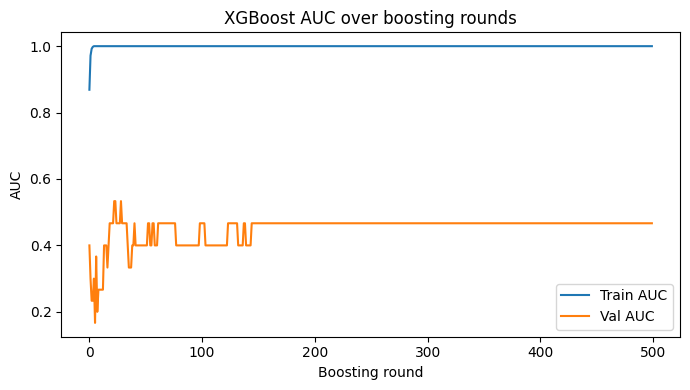

Validation ACC: 0.625
Validation AUC: 0.467


In [73]:
# Classification version with AUC over boosting rounds (Diff median split)
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise ImportError("xgboost is required for this cell. Install with: pip install xgboost") from exc

# Require grouped features and Diff labels
if "X_grouped" not in globals() or "y" not in globals():
    raise RuntimeError("Run the 'Diff prediction upgrades' cell first.")

# Binary labels from median split of Diff
y_class = (y >= np.median(y)).astype(int)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_grouped, y_class, test_size=0.1, random_state=42, stratify=y_class
)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    use_label_encoder=False,
)

# Fit with eval_set and early stopping if available
try:
    model.fit(
        X_train_s,
        y_train,
        eval_set=[(X_train_s, y_train), (X_val_s, y_val)],
        verbose=False,
        early_stopping_rounds=50,
    )
except TypeError:
    model.fit(
        X_train_s,
        y_train,
        eval_set=[(X_train_s, y_train), (X_val_s, y_val)],
        verbose=False,
    )

# Plot AUC over boosting rounds if available
if hasattr(model, "evals_result"):
    evals = model.evals_result()
    train_auc = evals.get("validation_0", {}).get("auc", [])
    val_auc = evals.get("validation_1", {}).get("auc", [])
    plt.figure(figsize=(7, 4))
    plt.plot(train_auc, label="Train AUC")
    plt.plot(val_auc, label="Val AUC")
    plt.xlabel("Boosting round")
    plt.ylabel("AUC")
    plt.title("XGBoost AUC over boosting rounds")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Final validation metrics
val_probs = model.predict_proba(X_val_s)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)
acc = accuracy_score(y_val, val_preds)
auc = roc_auc_score(y_val, val_probs)
print(f"Validation ACC: {acc:.3f}")
print(f"Validation AUC: {auc:.3f}")


Best silhouette: 0.474 with 3834 features


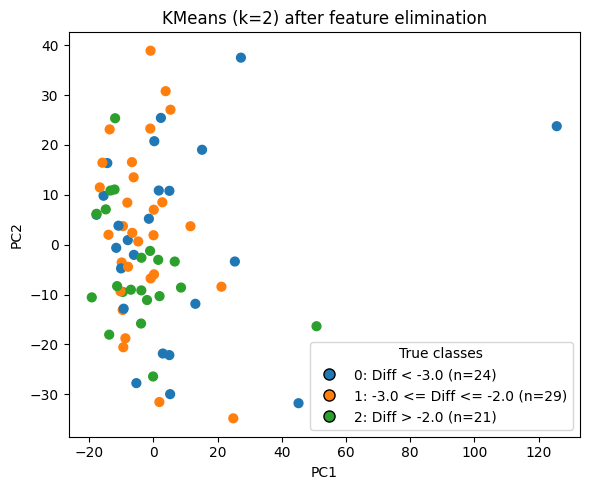

In [77]:
# Unsupervised clustering (k=2) with feature elimination by clustering quality
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use grouped features if available
if "X_grouped" in globals():
    X_use = X_grouped
else:
    raise RuntimeError("Run the 'Diff prediction upgrades' cell first to build X_grouped.")

# Standardize once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_use)

# Start with all features and iteratively drop lowest-variance features
current_idx = list(range(X_scaled.shape[1]))
results = []

# limit iterations to keep runtime reasonable
max_steps = min(15, max(1, len(current_idx) // 10))

for step in range(max_steps):
    X_sub = X_scaled[:, current_idx]

    # KMeans with 2 clusters
    km = KMeans(n_clusters=2, n_init=50, random_state=42)
    labels = km.fit_predict(X_sub)

    # Silhouette score = clustering quality (higher is better)
    sil = silhouette_score(X_sub, labels)
    results.append((len(current_idx), sil, current_idx.copy()))

    # Drop bottom 10% by variance
    if len(current_idx) <= 5:
        break
    variances = X_sub.var(axis=0)
    n_drop = max(1, len(current_idx) // 10)
    drop_local = np.argsort(variances)[:n_drop]
    current_idx = [c for i, c in enumerate(current_idx) if i not in drop_local]

# Pick best feature set by silhouette
best = max(results, key=lambda r: r[1])
best_idx = best[2]
print(f"Best silhouette: {best[1]:.3f} with {best[0]} features")

# Final clustering using best features
X_best = X_scaled[:, best_idx]
km = KMeans(n_clusters=2, n_init=50, random_state=42)
labels = km.fit_predict(X_best)

# 2D PCA plot (points colored by Diff range)
# Use same thresholds as earlier: vmin/vmax for 3 classes
vmin, vmax = -3.0, -2.0

y_true = np.where(y < vmin, 0, np.where(y > vmax, 2, 1)).astype(int)

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_best)

# Discrete colors + legend (same key as earlier)
cmap3 = ListedColormap(["tab:blue", "tab:orange", "tab:green"])
norm3 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], ncolors=3)
counts_true = {c: int((y_true == c).sum()) for c in [0, 1, 2]}
true_labels = {
    0: f"0: Diff < {vmin} (n={counts_true[0]})",
    1: f"1: {vmin} <= Diff <= {vmax} (n={counts_true[1]})",
    2: f"2: Diff > {vmax} (n={counts_true[2]})",
}
handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor=cmap3(i), markeredgecolor='k',
           markersize=8, label=true_labels[i])
    for i in [0, 1, 2]
]

plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=y_true, cmap=cmap3, norm=norm3, s=40)
plt.title("KMeans (k=2) after feature elimination")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(handles=handles, title="True classes", loc="best", frameon=True)
plt.tight_layout()
plt.show()
